# Brain Signal Analysis Pipeline (v2 | per-cluster BrainLM)

This v2 notebook is **intended for training one BrainLM per CM-cluster** and extracting **per-cluster latents**.

Pipeline:
- Segmentation
- Connectivity matrices (Pearson r or Fisher z)
- CM clustering
- Per-cluster fixed-length sequence tokenization + per-cluster train/val/test split
- **Per-cluster BrainLM training** + latent extraction

Notes:
- Outputs are saved with a suffix (`_r`/`_z`) to avoid collisions.
- Per-cluster models live in different representation spaces; compare clusters via downstream metrics/plots with care.

**SEQ_LEN / STRIDE:** Defaults in the config cell seed `build_cluster_sequences`. Run the scan + grid cells to drop empty-split combos; `rank` picks a low **val_loss** combo for a short training budget. The final training cell uses `rank.loc[0]` when available, then you can re-run with more epochs.


In [2]:
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('MTAD-GAT')


In [3]:
# --- safety knobs (reduce kernel crashes) ---
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import sys
from pathlib import Path

# Ensure MTAD-GAT root is on sys.path (so `import pipeline` works regardless of cwd)
_cwd = Path.cwd().resolve()
_candidates = [_cwd, _cwd / "MTAD-GAT", _cwd.parent]
for _p in _candidates:
    if (_p / "pipeline").exists():
        sys.path.insert(0, str(_p))
        break

import numpy as np
import pandas as pd
import torch

# device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device:', device)

# paths
ROOT = Path(sys.path[0])
DATA_PATH = ROOT / 'data' / 'DATA'
RESULT_PATH = ROOT / 'result'
OUTPUT_PATH = ROOT / 'visualization_ver2'
CHECKPOINT_PATH = ROOT / 'checkpoint' / 'brainlm_v2'
SPLIT_DIR = ROOT / 'data' / 'DATA' / 'data_pre' / 'split_info'

OUTPUT_PATH.mkdir(exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('DATA_PATH:', DATA_PATH)
print('RESULT_PATH:', RESULT_PATH)
print('OUTPUT_PATH:', OUTPUT_PATH)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)

Using device: mps
ROOT: /Users/mac/Desktop/code/MTAD-GAT
DATA_PATH: /Users/mac/Desktop/code/MTAD-GAT/data/DATA
RESULT_PATH: /Users/mac/Desktop/code/MTAD-GAT/result
OUTPUT_PATH: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2
CHECKPOINT_PATH: /Users/mac/Desktop/code/MTAD-GAT/checkpoint/brainlm_v2


In [4]:
# --- user switches ---
USE_FISHER_Z = True   # False=r, True=Fisher z
OUTPUT_SUFFIX = 'z' if USE_FISHER_Z else 'r'

# clustering
K = 4                 # set K (or make this dynamic if you want)

# BrainLM sequence settings (initial guess; grid search + `rank` selects the combo for final training)
# Smaller SEQ_LEN/STRIDE => many more sequences
SEQ_LEN = 8
STRIDE = 2
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1
MASK_RATIO = 0.15

# perf / safety
MAX_CMS_PER_CLUSTER = None   # e.g., 500 to cap per cluster (None = no cap)
MAX_SEQS_PER_CLUSTER = None  # e.g., 2000 to cap sequences per cluster

print('USE_FISHER_Z:', USE_FISHER_Z)
print('K:', K)
print('SEQ_LEN:', SEQ_LEN, 'STRIDE:', STRIDE)


USE_FISHER_Z: True
K: 4
SEQ_LEN: 8 STRIDE: 2


In [5]:
# --- Phase 2: Segmentation (match v1 behavior) ---
from pipeline.segmentation import segment_all_subjects, get_segment_statistics

SEGMENTATION_METHOD = 'embedding'  # 'anomaly' | 'anomaly_smooth' | 'embedding'
MTAD_GAT_CHECKPOINT = ROOT / 'checkpoint' / 'global_checkpoint_iter_0.pkl'

if SEGMENTATION_METHOD == 'embedding':
    from pipeline.segmentation_evaluation import segment_all_subjects_embedding
    print(f"Segmenting with method: {SEGMENTATION_METHOD} (embedding change-based)")
    all_segments = segment_all_subjects_embedding(
        data_path=DATA_PATH,
        checkpoint_path=MTAD_GAT_CHECKPOINT,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        top_k=20,
        smooth_window=5,
        device=device,
        data_pre_path=SPLIT_DIR.parent,
        verbose=True,
    )
else:
    print(f"Segmenting with method: {SEGMENTATION_METHOD}...")
    all_segments = segment_all_subjects(
        data_path=DATA_PATH,
        result_path=RESULT_PATH,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        method=SEGMENTATION_METHOD,
        smooth_window=5,
    )

segment_stats = get_segment_statistics(all_segments)
print(f"\nTotal segments: {len(segment_stats)}")
print(f"Subjects processed: {segment_stats['subject_id'].nunique()}")
print(f"Average segment length: {segment_stats['length'].mean():.2f}")
print(f"Segments per subject: {segment_stats.groupby('subject_id').size().mean():.2f}")


/opt/anaconda3/envs/tf_m4/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Segmenting with method: embedding (embedding change-based)


Embedding segmentation:   4%|▎         | 1/27 [00:05<02:13,  5.14s/it]

Subject 108828: 14 segments


Embedding segmentation:   7%|▋         | 2/27 [00:10<02:05,  5.04s/it]

...

Subject 102816: 11 segments


Embedding segmentation:  96%|█████████▋| 26/27 [02:10<00:05,  5.05s/it]

Subject 121416: 8 segments


Embedding segmentation: 100%|██████████| 27/27 [02:15<00:00,  5.03s/it]

Subject 111514: 11 segments

Total segments: 308
Subjects processed: 27
Average segment length: 105.19
Segments per subject: 11.41


In [6]:
# --- Phase 3: CM computation (r or z) ---
from pipeline.connectivity import compute_all_cms, collect_all_cms_flat

print(f"Computing CMs... (USE_FISHER_Z={USE_FISHER_Z})")
all_cms = compute_all_cms(all_segments, method='pearson', min_segment_len=10, use_fisher_z=USE_FISHER_Z)
X, cm_labels = collect_all_cms_flat(all_cms)
print('Total CMs:', len(cm_labels), 'Feature dim:', X.shape[1])


Computing CMs... (USE_FISHER_Z=True)
Subject 108828: 14 CMs computed
Subject 113316: 12 CMs computed
Subject 111211: 13 CMs computed
Subject 119025: 11 CMs computed
Subject 113215: 10 CMs computed
Subject 107018: 9 CMs computed
Subject 120717: 13 CMs computed
Subject 113619: 11 CMs computed
Subject 114419: 11 CMs computed
Subject 120515: 12 CMs computed
Subject 108121: 12 CMs computed
Subject 106319: 9 CMs computed
Subject 100307: 14 CMs computed
Subject 111716: 12 CMs computed
Subject 104416: 13 CMs computed
Subject 100408: 13 CMs computed
Subject 105014: 13 CMs computed
Subject 120111: 8 CMs computed
Subject 117122: 11 CMs computed
Subject 119732: 14 CMs computed
Subject 118831: 10 CMs computed
Subject 103818: 11 CMs computed
Subject 113922: 12 CMs computed
Subject 116524: 10 CMs computed
Subject 102816: 11 CMs computed
Subject 121416: 8 CMs computed
Subject 111514: 11 CMs computed
Total CMs: 308 Feature dim: 4950


Clustering with K=4 (MiniBatchKMeans)
Silhouette score: 0.0000
Cluster sizes: {np.int32(0): np.int64(99), np.int32(1): np.int64(121), np.int32(2): np.int64(72), np.int32(3): np.int64(16)}
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/cluster_distribution_z.png


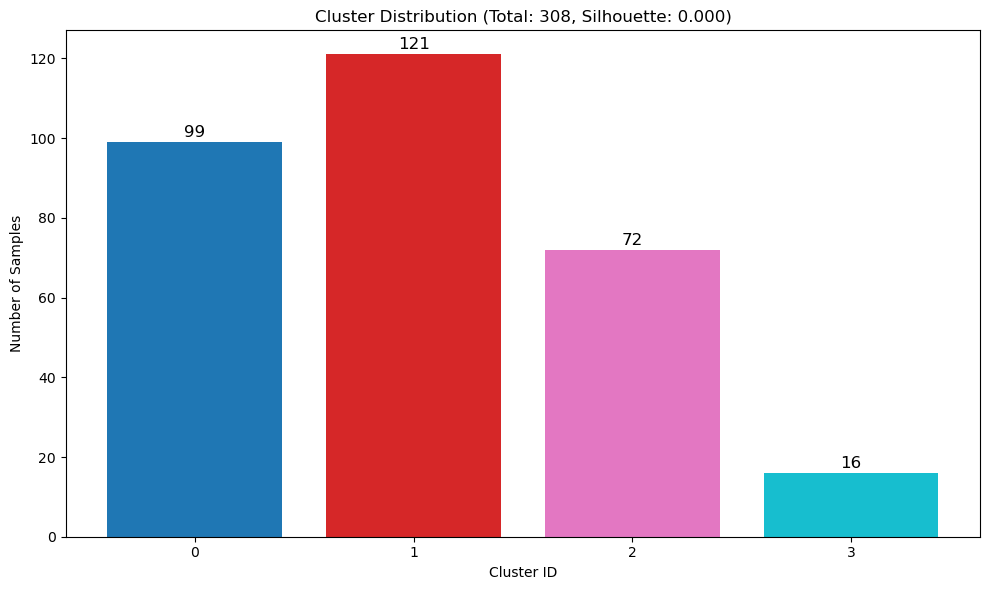

In [7]:
# --- Phase 4: Clustering ---
from pipeline.clustering import perform_clustering
from pipeline.visualization import plot_cluster_distribution

print(f"Clustering with K={K} (MiniBatchKMeans)")
clustering_result = perform_clustering(
    X,
    cm_labels,
    n_clusters=K,
    use_minibatch=True,
    n_init=4,
    max_iter=200,
    batch_size=256,
    skip_silhouette=True,
)

print(f"Silhouette score: {clustering_result.silhouette:.4f}")
print('Cluster sizes:', clustering_result.get_cluster_sizes())

fig = plot_cluster_distribution(clustering_result, show=False)
out_dist = OUTPUT_PATH / f'cluster_distribution_{OUTPUT_SUFFIX}.png'
fig.savefig(out_dist, dpi=150)
print('Saved:', out_dist)


/Users/mac/Desktop/code/MTAD-GAT/pipeline/visualization.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/cluster_centroids_z.png


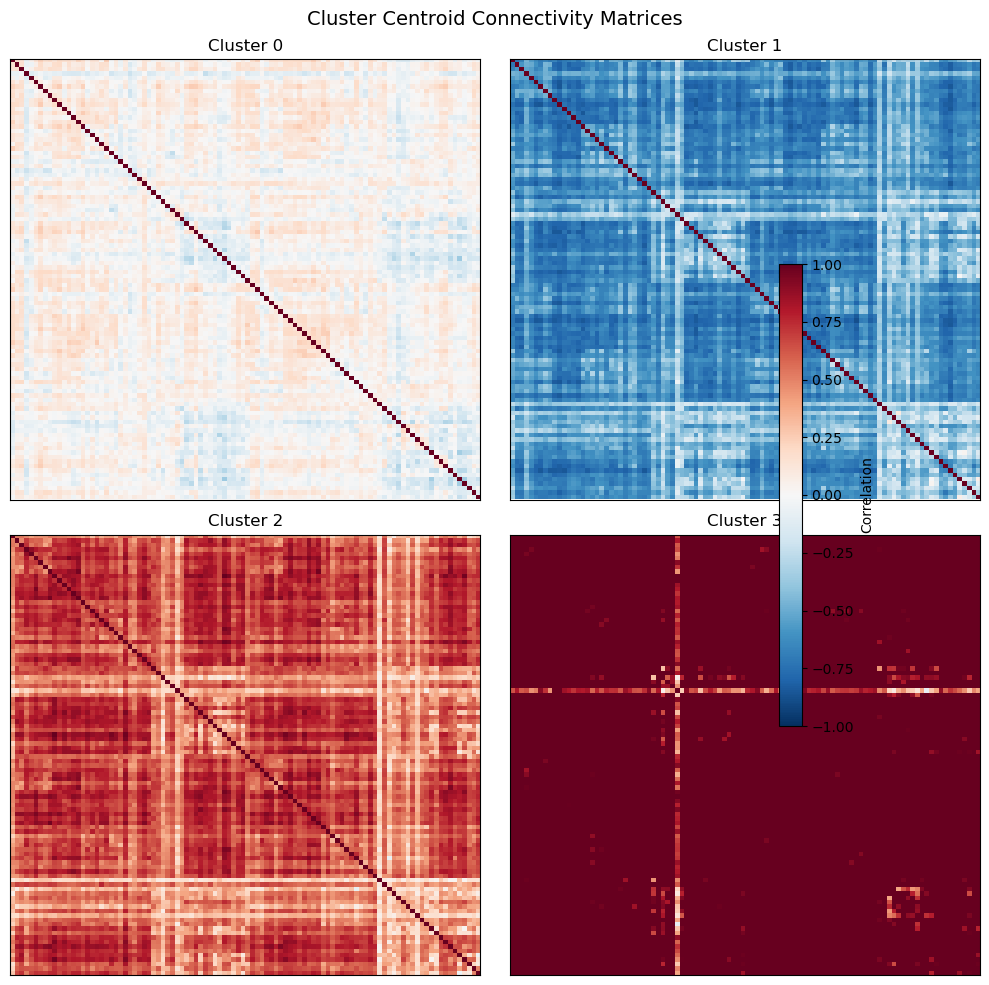

In [8]:
# --- Cluster centroid CM visualization (same as full_pipeline v1) ---
from pipeline.clustering import get_cluster_centroids
from pipeline.visualization import plot_cluster_centroids

n_features = next(iter(all_cms.values()))[0].n_features
centroids = get_cluster_centroids(clustering_result, n_features=n_features)

# 2x2 layout when K=4 (figsize tuned for four panels + shared colorbar)
fig = plot_cluster_centroids(
    centroids,
    figsize=(10, 10),
    n_cols=2 if len(centroids) == 4 else None,
    show=False,
)
out = OUTPUT_PATH / f'cluster_centroids_{OUTPUT_SUFFIX}.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print('Saved:', out)


Computing subject-cluster similarities...
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/subject_cluster_similarity_z.png


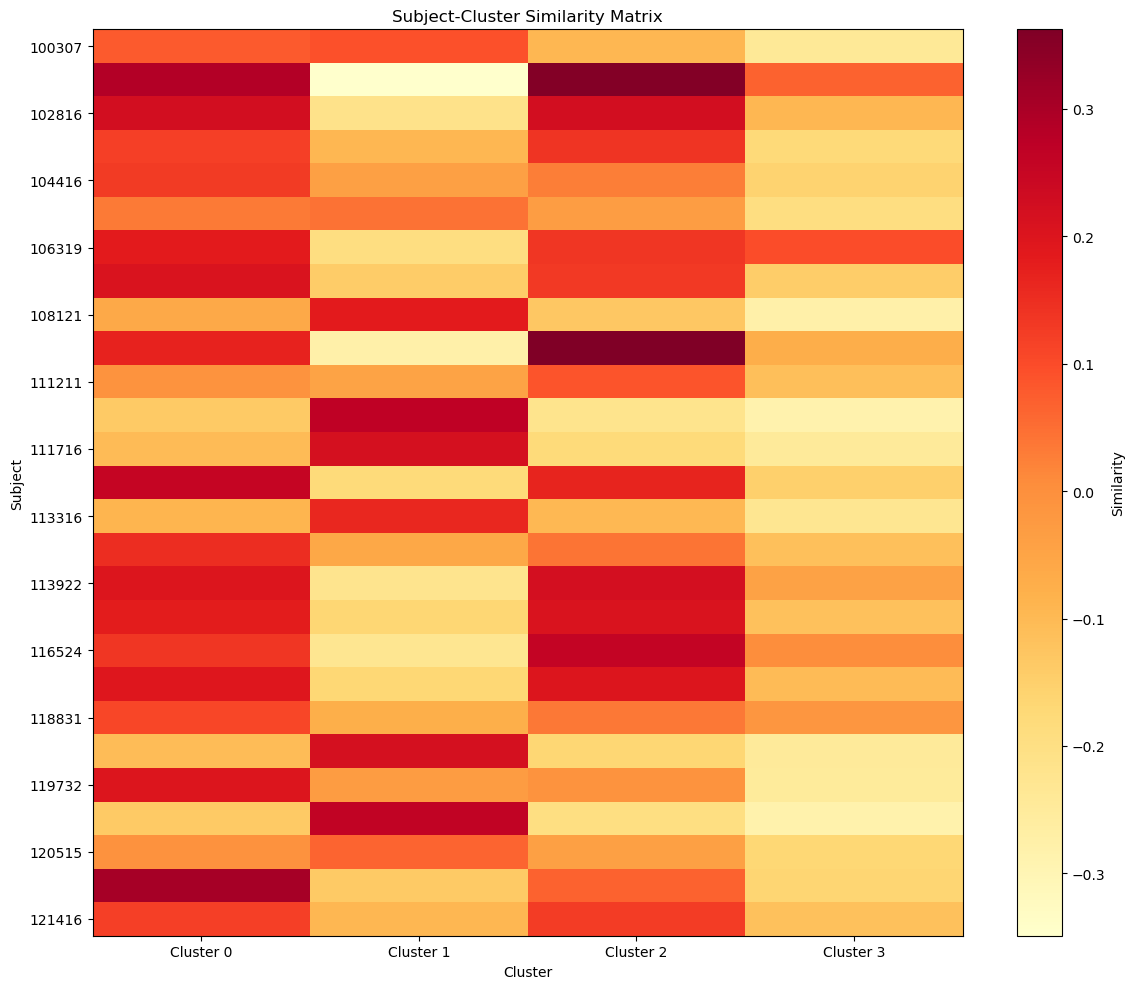

In [9]:
# Compute similarity between individual CMs and cluster centroids (v1)
from pipeline.clustering import compute_cluster_similarity
from pipeline.visualization import plot_similarity_matrix

n_features = next(iter(all_cms.values()))[0].n_features
print("Computing subject-cluster similarities...")
similarities = compute_cluster_similarity(all_cms, clustering_result, n_features=n_features)

fig = plot_similarity_matrix(similarities, show=False)
out_sim = OUTPUT_PATH / f'subject_cluster_similarity_{OUTPUT_SUFFIX}.png'
fig.savefig(out_sim, dpi=150)
print('Saved:', out_sim)

In [10]:
# Compare clustering quality between Pearson r-CM vs Fisher z-CM (v1)
import pandas as pd

from pipeline.connectivity import compute_all_cms, collect_all_cms_flat
from pipeline.clustering import perform_clustering

COMPARE_K = K
COMPARE_SAMPLE_N = None
COMPARE_SKIP_SILHOUETTE = True

rows = []
for use_z in [False, True]:
    cm_type = 'fisher_z' if use_z else 'pearson_r'
    print(f"\n[Compare] Building CMs: {cm_type}")
    cms = compute_all_cms(all_segments, method='pearson', min_segment_len=10, use_fisher_z=use_z)
    X_cmp, labels_cmp = collect_all_cms_flat(cms)

    if COMPARE_SAMPLE_N is not None and len(X_cmp) > COMPARE_SAMPLE_N:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(X_cmp), size=COMPARE_SAMPLE_N, replace=False)
        X_use = X_cmp[idx]
        labels_use = [labels_cmp[i] for i in idx]
    else:
        X_use = X_cmp
        labels_use = labels_cmp

    print(f"[Compare] Clustering: {cm_type} | samples={len(X_use)} | dim={X_use.shape[1]} | K={COMPARE_K}")
    res = perform_clustering(
        X_use,
        labels_use,
        n_clusters=COMPARE_K,
        use_minibatch=True,
        n_init=1,
        max_iter=200,
        batch_size=256,
        skip_silhouette=COMPARE_SKIP_SILHOUETTE,
    )

    sizes = res.get_cluster_sizes()
    rows.append({
        'cm_type': cm_type,
        'use_fisher_z': use_z,
        'n_samples': int(len(X_use)),
        'n_dim': int(X_use.shape[1]),
        'k': int(res.n_clusters),
        'inertia': float(res.inertia),
        'silhouette': float(res.silhouette),
        'cluster_sizes': sizes,
        'cluster_size_min': int(min(sizes.values())) if sizes else 0,
        'cluster_size_max': int(max(sizes.values())) if sizes else 0,
    })

quality_df = pd.DataFrame(rows)
quality_df

out_csv = OUTPUT_PATH / 'clustering_quality_r_vs_z.csv'
quality_df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")


[Compare] Building CMs: pearson_r
Subject 108828: 14 CMs computed
Subject 113316: 12 CMs computed
Subject 111211: 13 CMs computed
Subject 119025: 11 CMs computed
Subject 113215: 10 CMs computed
Subject 107018: 9 CMs computed
Subject 120717: 13 CMs computed
Subject 113619: 11 CMs computed
Subject 114419: 11 CMs computed
Subject 120515: 12 CMs computed
Subject 108121: 12 CMs computed
Subject 106319: 9 CMs computed
Subject 100307: 14 CMs computed
Subject 111716: 12 CMs computed
Subject 104416: 13 CMs computed
Subject 100408: 13 CMs computed
Subject 105014: 13 CMs computed
Subject 120111: 8 CMs computed
Subject 117122: 11 CMs computed
Subject 119732: 14 CMs computed
Subject 118831: 10 CMs computed
Subject 103818: 11 CMs computed
Subject 113922: 12 CMs computed
Subject 116524: 10 CMs computed
Subject 102816: 11 CMs computed
Subject 121416: 8 CMs computed
Subject 111514: 11 CMs computed
[Compare] Clustering: pearson_r | samples=308 | dim=4950 | K=4

[Compare] Building CMs: fisher_z
Subject 

In [11]:
# --- Build fixed-length CM sequences per cluster + per-cluster train/val/test split ---
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from pipeline.clustering import flatten_cm

@dataclass
class SeqExample:
    tokens: np.ndarray       # (seq_len, feat_dim)
    cluster_id: int


def _flatten_cm_obj(cm_obj, use_upper_triangle=True):
    if use_upper_triangle:
        return flatten_cm(cm_obj.matrix).astype(np.float32)
    return cm_obj.matrix.flatten().astype(np.float32)


def build_cluster_sequences(all_cms_dict, cm_labels_list, cluster_labels_flat, seq_len=16, stride=8,
                            use_upper_triangle=True,
                            max_cms_per_cluster=None,
                            max_seqs_per_cluster=None,
                            seed=42):
    """Return list[SeqExample].

    - all_cms_dict: {subject_id: [ConnectivityMatrix,...]}
    - cm_labels_list: list[(subject_id, segment_id)] aligned with flattened order used in X
    - cluster_labels_flat: np.ndarray aligned with cm_labels_list
    """
    rng = np.random.default_rng(seed)

    # map (subject, segment_id) -> cm object
    cm_lookup = {}
    for sid, cms in all_cms_dict.items():
        for cm in cms:
            cm_lookup[(sid, cm.segment_id)] = cm

    # per-cluster ordered list of keys (subject_id, segment_id)
    clusters = {}
    for key, cid in zip(cm_labels_list, cluster_labels_flat):
        clusters.setdefault(int(cid), []).append(key)

    examples = []
    for cid, keys in sorted(clusters.items()):
        # keep stable order: sort by subject_id then segment_id
        keys_sorted = sorted(keys, key=lambda x: (x[0], int(x[1])))
        if max_cms_per_cluster is not None and len(keys_sorted) > max_cms_per_cluster:
            keys_sorted = list(rng.choice(keys_sorted, size=max_cms_per_cluster, replace=False))

        # make token array
        feats = []
        for k in keys_sorted:
            cm = cm_lookup.get(k)
            if cm is None:
                continue
            feats.append(_flatten_cm_obj(cm, use_upper_triangle=use_upper_triangle))
        feats = np.asarray(feats, dtype=np.float32)

        if len(feats) < seq_len:
            continue

        # sliding windows
        starts = list(range(0, len(feats) - seq_len + 1, stride))
        if max_seqs_per_cluster is not None and len(starts) > max_seqs_per_cluster:
            starts = list(rng.choice(starts, size=max_seqs_per_cluster, replace=False))

        for s in starts:
            ex = SeqExample(tokens=feats[s:s+seq_len].copy(), cluster_id=cid)
            examples.append(ex)

    return examples


def split_by_cluster(examples, val_split=0.1, test_split=0.1, seed=42):
    rng = np.random.default_rng(seed)
    by_c = {}
    for ex in examples:
        by_c.setdefault(ex.cluster_id, []).append(ex)

    train, val, test = [], [], []
    for cid, exs in by_c.items():
        exs = list(exs)
        rng.shuffle(exs)
        n = len(exs)
        n_test = int(round(n * test_split))
        n_val = int(round(n * val_split))
        n_train = max(0, n - n_val - n_test)

        train.extend(exs[:n_train])
        val.extend(exs[n_train:n_train+n_val])
        test.extend(exs[n_train+n_val:])

    return train, val, test


class ClusterSeqDataset(Dataset):
    def __init__(self, examples, mask_ratio=0.15):
        self.examples = examples
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        x = ex.tokens.copy()  # (seq_len, feat_dim)
        labels = ex.tokens.copy()

        seq_len = x.shape[0]
        mask_labels = np.zeros(seq_len, dtype=np.float32)
        if self.mask_ratio and self.mask_ratio > 0:
            n_mask = max(1, int(seq_len * self.mask_ratio))
            mask_idx = np.random.choice(seq_len, n_mask, replace=False)
            mask_labels[mask_idx] = 1.0
            # replace masked positions with noise (simple)
            x[mask_idx] = np.random.randn(n_mask, x.shape[1]).astype(np.float32) * 0.1

        attention_mask = np.ones(seq_len, dtype=np.float32)

        return {
            'input_ids': torch.from_numpy(x).float(),
            'attention_mask': torch.from_numpy(attention_mask).float(),
            'labels': torch.from_numpy(labels).float(),
            'mask_labels': torch.from_numpy(mask_labels).float(),
            'cluster_ids': torch.full((seq_len,), int(ex.cluster_id), dtype=torch.long),
        }


def _count_by_cluster(examples):
    d = {}
    for ex in examples:
        d[int(ex.cluster_id)] = d.get(int(ex.cluster_id), 0) + 1
    return d


print('Building per-cluster sequences...')
seq_examples = build_cluster_sequences(
    all_cms_dict=all_cms,
    cm_labels_list=cm_labels,
    cluster_labels_flat=clustering_result.labels,
    seq_len=SEQ_LEN,
    stride=STRIDE,
    use_upper_triangle=True,
    max_cms_per_cluster=MAX_CMS_PER_CLUSTER,
    max_seqs_per_cluster=MAX_SEQS_PER_CLUSTER,
)
print('Total sequences:', len(seq_examples))

train_ex, val_ex, test_ex = split_by_cluster(seq_examples, val_split=VAL_SPLIT, test_split=TEST_SPLIT)
print('Train/Val/Test:', len(train_ex), len(val_ex), len(test_ex))

train_ds = ClusterSeqDataset(train_ex, mask_ratio=MASK_RATIO)
val_ds = ClusterSeqDataset(val_ex, mask_ratio=MASK_RATIO)
test_ds = ClusterSeqDataset(test_ex, mask_ratio=0.0)  # no masking for extraction

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)


Building per-cluster sequences...
Total sequences: 141
Train/Val/Test: 113 14 14


In [12]:
# --- Quick check: number of sequences per cluster (total/train/val/test) ---
import pandas as pd

counts_total = _count_by_cluster(seq_examples)
counts_train = _count_by_cluster(train_ex)
counts_val = _count_by_cluster(val_ex)
counts_test = _count_by_cluster(test_ex)

rows = []
all_cids = sorted(set(counts_total) | set(counts_train) | set(counts_val) | set(counts_test))
for cid in all_cids:
    rows.append({
        'cluster_id': cid,
        'seq_total': counts_total.get(cid, 0),
        'seq_train': counts_train.get(cid, 0),
        'seq_val': counts_val.get(cid, 0),
        'seq_test': counts_test.get(cid, 0),
    })

df_seq = pd.DataFrame(rows).sort_values('cluster_id').reset_index(drop=True)
print('Total sequences:', len(seq_examples))
print('Train/Val/Test:', len(train_ex), len(val_ex), len(test_ex))

df_seq

Total sequences: 141
Train/Val/Test: 113 14 14


,cluster_id,seq_total,seq_train,seq_val,seq_test
0,0,46,36,5,5
1,1,57,45,6,6
2,2,33,27,3,3
3,3,5,5,0,0


In [13]:
# --- Quick experiment: scan (SEQ_LEN, STRIDE) to find a good operating point ---
# This does NOT train BrainLM. It only measures how many sequences you get per cluster
# and whether per-cluster train/val/test splits become empty.

import pandas as pd
import numpy as np

# Candidate grid (edit as needed)
CANDIDATES = [
    (4, 1), (4, 2),
    (6, 1), (6, 2),
    (8, 1), (8, 2), (8, 4),
    (12, 2), (12, 4),
    (16, 4), (16, 8),
]

rows = []
for seq_len, stride in CANDIDATES:
    exs = build_cluster_sequences(
        all_cms_dict=all_cms,
        cm_labels_list=cm_labels,
        cluster_labels_flat=clustering_result.labels,
        seq_len=int(seq_len),
        stride=int(stride),
        use_upper_triangle=True,
        max_cms_per_cluster=MAX_CMS_PER_CLUSTER,
        max_seqs_per_cluster=MAX_SEQS_PER_CLUSTER,
        seed=42,
    )

    tr, va, te = split_by_cluster(exs, val_split=VAL_SPLIT, test_split=TEST_SPLIT, seed=42)

    c_total = _count_by_cluster(exs)
    c_tr = _count_by_cluster(tr)
    c_va = _count_by_cluster(va)
    c_te = _count_by_cluster(te)

    # Evaluate split health per cluster (after split)
    all_cids = sorted(set(c_total) | set(c_tr) | set(c_va) | set(c_te))
    n_clusters_present = len(all_cids)
    n_bad_clusters = 0
    min_total = None
    min_train = None
    min_val = None
    min_test = None
    for cid in all_cids:
        t = c_total.get(cid, 0)
        a = c_tr.get(cid, 0)
        b = c_va.get(cid, 0)
        c = c_te.get(cid, 0)
        if (a == 0) or (b == 0) or (c == 0):
            n_bad_clusters += 1
        min_total = t if (min_total is None) else min(min_total, t)
        min_train = a if (min_train is None) else min(min_train, a)
        min_val = b if (min_val is None) else min(min_val, b)
        min_test = c if (min_test is None) else min(min_test, c)

    rows.append({
        'seq_len': int(seq_len),
        'stride': int(stride),
        'n_seq_total': int(len(exs)),
        'n_seq_train': int(len(tr)),
        'n_seq_val': int(len(va)),
        'n_seq_test': int(len(te)),
        'n_clusters_present': int(n_clusters_present),
        'min_seq_total_per_cluster': int(min_total or 0),
        'min_seq_train_per_cluster': int(min_train or 0),
        'min_seq_val_per_cluster': int(min_val or 0),
        'min_seq_test_per_cluster': int(min_test or 0),
        'n_clusters_with_empty_split': int(n_bad_clusters),
    })

df_scan = pd.DataFrame(rows).sort_values(
    ['n_clusters_with_empty_split', 'n_seq_total', 'seq_len', 'stride'],
    ascending=[True, False, True, True]
).reset_index(drop=True)

# Top suggestions: fewer empty-split clusters, more data
print('Scan done. Best candidates are at the top (few empty-split clusters).')
df_scan

Scan done. Best candidates are at the top (few empty-split clusters).


,seq_len,stride,n_seq_total,n_seq_train,n_seq_val,n_seq_test,n_clusters_present,min_seq_total_per_cluster,min_seq_train_per_cluster,min_seq_val_per_cluster,min_seq_test_per_cluster,n_clusters_with_empty_split
0,4,1,296,236,30,30,4,13,11,1,1,0
1,6,1,288,230,29,29,4,11,9,1,1,0
2,8,1,280,226,27,27,4,9,7,1,1,0
3,4,2,149,117,16,16,4,7,5,1,1,0
4,6,2,145,115,15,15,4,6,4,1,1,0
5,8,2,141,113,14,14,4,5,5,0,0,1
6,12,2,133,107,13,13,4,3,3,0,0,1
7,8,4,72,58,7,7,4,3,3,0,0,1
8,12,4,68,54,7,7,4,2,2,0,0,1
9,16,4,64,50,7,7,4,1,1,0,0,1


In [14]:
# --- Grid runner: train per-cluster BrainLM for candidates with no empty split ---
# Requires df_scan from the scan cell.
# Saves per-combo outputs under OUTPUT_PATH / 'grid_seq_len_stride' / ...

from pathlib import Path
import time
import json
import numpy as np
import pandas as pd

from brainlm.model import BrainLMConfig
from brainlm.train import train_brainlm, extract_latents, evaluate_loss
from torch.utils.data import DataLoader

assert 'df_scan' in globals(), "Run the scan cell first to create df_scan."

# Only combos where every cluster has train/val/test >= 1
candidates_ok = df_scan[df_scan['n_clusters_with_empty_split'] == 0].copy()
print('Candidates with n_clusters_with_empty_split == 0:', len(candidates_ok))

# Controls (adjust for speed)
MAX_EPOCHS_GRID = 10      # quick sweep; rerun best combos with higher epochs
LR_GRID = 1e-4
PATIENCE_GRID = 5
BATCH_SIZE_GRID = 32

# Where to save everything
GRID_DIR = OUTPUT_PATH / 'grid_seq_len_stride'
GRID_DIR.mkdir(parents=True, exist_ok=True)

rows = []  # one row per (seq_len, stride, cluster_id)

for _, r in candidates_ok.iterrows():
    seq_len = int(r['seq_len'])
    stride = int(r['stride'])

    combo_tag = f'seq{seq_len}_st{stride}_{OUTPUT_SUFFIX}'
    combo_out = GRID_DIR / combo_tag
    combo_out.mkdir(parents=True, exist_ok=True)

    combo_ckpt_root = CHECKPOINT_PATH / 'grid_seq_len_stride' / combo_tag
    combo_ckpt_root.mkdir(parents=True, exist_ok=True)

    # Skip if already completed (summary exists)
    combo_summary_path = combo_out / f'pipeline_summary_v2_per_cluster_{combo_tag}.json'
    combo_csv_path = combo_out / f'results_{combo_tag}.csv'
    if combo_summary_path.exists() and combo_csv_path.exists():
        print(f"[skip] already exists: {combo_tag}")
        continue

    print(f"\n=== Combo: SEQ_LEN={seq_len}, STRIDE={stride} ({combo_tag}) ===")

    # Rebuild sequences + split for this combo
    seq_examples_combo = build_cluster_sequences(
        all_cms_dict=all_cms,
        cm_labels_list=cm_labels,
        cluster_labels_flat=clustering_result.labels,
        seq_len=seq_len,
        stride=stride,
        use_upper_triangle=True,
        max_cms_per_cluster=MAX_CMS_PER_CLUSTER,
        max_seqs_per_cluster=MAX_SEQS_PER_CLUSTER,
        seed=42,
    )

    train_ex_c, val_ex_c, test_ex_c = split_by_cluster(
        seq_examples_combo,
        val_split=VAL_SPLIT,
        test_split=TEST_SPLIT,
        seed=42,
    )

    # Group seq examples by cluster for iteration
    by_cluster = {}
    for ex in seq_examples_combo:
        by_cluster.setdefault(int(ex.cluster_id), []).append(ex)

    cluster_summaries_combo = []
    combo_rows = []

    for cid in sorted(by_cluster.keys()):
        c_train = [ex for ex in train_ex_c if int(ex.cluster_id) == cid]
        c_val   = [ex for ex in val_ex_c   if int(ex.cluster_id) == cid]
        c_test  = [ex for ex in test_ex_c  if int(ex.cluster_id) == cid]

        # Safety (should not trigger for filtered candidates)
        if len(c_train) == 0 or len(c_val) == 0 or len(c_test) == 0:
            combo_rows.append({
                'combo': combo_tag,
                'seq_len': seq_len,
                'stride': stride,
                'cluster_id': cid,
                'status': 'skip_empty_split',
                'n_train': len(c_train),
                'n_val': len(c_val),
                'n_test': len(c_test),
            })
            continue

        print(f"cluster {cid}: seq (train/val/test) = {len(c_train)}/{len(c_val)}/{len(c_test)}")

        c_train_loader = DataLoader(ClusterSeqDataset(c_train, mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_GRID, shuffle=True,  num_workers=0)
        c_val_loader   = DataLoader(ClusterSeqDataset(c_val,   mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_GRID, shuffle=False, num_workers=0)
        c_test_eval_loader = DataLoader(ClusterSeqDataset(c_test, mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_GRID, shuffle=False, num_workers=0)

        ckpt_dir = combo_ckpt_root / f'cluster_{cid}'
        ckpt_dir.mkdir(parents=True, exist_ok=True)

        config = BrainLMConfig(
            n_features=100,
            d_model=256,
            nhead=8,
            num_encoder_layers=4,
            num_decoder_layers=2,
            dim_feedforward=1024,
            dropout=0.1,
            max_seq_len=seq_len,
            mask_ratio=MASK_RATIO,
            use_upper_triangle=True,
        )

        t0 = time.time()
        model, history = train_brainlm(
            train_loader=c_train_loader,
            val_loader=c_val_loader,
            config=config,
            max_epochs=MAX_EPOCHS_GRID,
            lr=LR_GRID,
            patience=PATIENCE_GRID,
            checkpoint_dir=ckpt_dir,
            device=device,
        )
        elapsed_s = float(time.time() - t0)

        # Performance: test split only (masked loss, same as val)
        final_test_loss = evaluate_loss(model, c_test_eval_loader, device)

        # Manifold / viz latents: train + val + test (no masking)
        c_all_ex = list(c_train) + list(c_val) + list(c_test)
        c_all_loader = DataLoader(
            ClusterSeqDataset(c_all_ex, mask_ratio=0.0),
            batch_size=BATCH_SIZE_GRID, shuffle=False, num_workers=0,
        )
        latents, cluster_ids = extract_latents(model, c_all_loader, device)

        lat_path = combo_out / f'latents_v2_cluster{cid}_{combo_tag}.npy'
        cid_path = combo_out / f'cluster_ids_v2_cluster{cid}_{combo_tag}.npy'
        np.save(lat_path, latents)
        np.save(cid_path, cluster_ids)

        summary = {
            'version': 'v2_per_cluster_grid',
            'combo': combo_tag,
            'cluster_id': int(cid),
            'cm_value_type': 'fisher_z' if USE_FISHER_Z else 'pearson_r',
            'k': int(K),
            'seq_len': int(seq_len),
            'stride': int(stride),
            'n_sequences_train': int(len(c_train)),
            'n_sequences_val': int(len(c_val)),
            'n_sequences_test': int(len(c_test)),
            'final_train_loss': float(history['train_loss'][-1]),
            'final_val_loss': float(history['val_loss'][-1]),
            'latents_path': str(lat_path),
            'cluster_ids_path': str(cid_path),
            'checkpoint_dir': str(ckpt_dir),
            'elapsed_s': elapsed_s,
        }
        cluster_summaries_combo.append(summary)

        combo_rows.append({
            'combo': combo_tag,
            'seq_len': seq_len,
            'stride': stride,
            'cluster_id': int(cid),
            'status': 'ok',
            'n_train': int(len(c_train)),
            'n_val': int(len(c_val)),
            'n_test': int(len(c_test)),
            'final_train_loss': float(history['train_loss'][-1]),
            'final_val_loss': float(history['val_loss'][-1]),
            'final_test_loss': float(final_test_loss),
            'n_latents': int(len(c_all_ex)),
            'latent_split': 'train_val_test',
            'elapsed_s': elapsed_s,
            'latents_path': str(lat_path),
            'checkpoint_dir': str(ckpt_dir),
        })

    # Save combo summary + csv
    with open(combo_summary_path, 'w') as f:
        json.dump({'clusters': cluster_summaries_combo}, f, indent=2)

    df_combo = pd.DataFrame(combo_rows)
    df_combo.to_csv(combo_csv_path, index=False)

    rows.extend(combo_rows)
    print('Saved:', combo_csv_path)
    print('Saved:', combo_summary_path)

# Save aggregated CSV (do not overwrite with an empty file if the loop was interrupted)
agg_path = GRID_DIR / f'grid_results_{OUTPUT_SUFFIX}.csv'
if rows:
    pd.DataFrame(rows).to_csv(agg_path, index=False)
    print('\nSaved aggregated grid CSV to', agg_path)
else:
    combo_csvs = sorted(GRID_DIR.glob(f'seq*_{OUTPUT_SUFFIX}/results_seq*_{OUTPUT_SUFFIX}.csv'))
    if combo_csvs:
        pd.concat([pd.read_csv(p) for p in combo_csvs], ignore_index=True).to_csv(agg_path, index=False)
        print(f'\n[warn] grid loop produced no new rows; rebuilt aggregated CSV from {len(combo_csvs)} combo file(s):', agg_path)
    else:
        print(f'\n[warn] no rows to save; left existing file alone: {agg_path}')


Candidates with n_clusters_with_empty_split == 0: 5
[skip] already exists: seq4_st1_z
[skip] already exists: seq6_st1_z
[skip] already exists: seq8_st1_z
[skip] already exists: seq4_st2_z
[skip] already exists: seq6_st2_z

[warn] grid loop produced no new rows; rebuilt aggregated CSV from 5 combo file(s): /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/grid_seq_len_stride/grid_results_z.csv


In [15]:
# --- Analyze grid results: rank (SEQ_LEN, STRIDE) combos ---
# Reads grid_results_*.csv from the grid runner, or rebuilds it from per-combo CSVs.

from pathlib import Path
import pandas as pd

GRID_DIR = OUTPUT_PATH / 'grid_seq_len_stride'
agg_path = GRID_DIR / f'grid_results_{OUTPUT_SUFFIX}.csv'


def _load_grid_results(agg_path: Path, grid_dir: Path, suffix: str) -> pd.DataFrame:
    """Load aggregated grid CSV; if empty/missing, stitch combo-level results_*.csv files."""
    if agg_path.exists() and agg_path.stat().st_size > 0:
        try:
            df = pd.read_csv(agg_path)
            if len(df) > 0:
                return df
        except pd.errors.EmptyDataError:
            pass

    combo_csvs = sorted(grid_dir.glob(f'seq*_{suffix}/results_seq*_{suffix}.csv'))
    if not combo_csvs:
        raise FileNotFoundError(
            f"No grid results at {agg_path} and no per-combo CSVs under {grid_dir}. "
            "Run the grid runner cell first (or finish it without interrupting)."
        )

    parts = [pd.read_csv(p) for p in combo_csvs]
    df = pd.concat(parts, ignore_index=True)
    df.to_csv(agg_path, index=False)
    print(f"[rebuilt] Wrote {len(df)} rows from {len(combo_csvs)} combo CSV(s) -> {agg_path}")
    return df


df_grid = _load_grid_results(agg_path, GRID_DIR, OUTPUT_SUFFIX)

# Normalize status
if 'status' not in df_grid.columns:
    raise ValueError('Expected a status column in grid_results CSV.')

df_grid['is_ok'] = (df_grid['status'] == 'ok')

# Rank by: fewer skips -> lower max val_loss -> lower mean val_loss
# (max is a good worst-case guard across clusters)
rank = (df_grid
        .groupby('combo', as_index=False)
        .agg(
            n_clusters=('cluster_id', 'nunique'),
            n_ok=('is_ok', 'sum'),
            n_skip=('is_ok', lambda s: int((~s).sum())),
            mean_val_loss=('final_val_loss', 'mean'),
            max_val_loss=('final_val_loss', 'max'),
            mean_elapsed_s=('elapsed_s', 'mean'),
        ))

rank = rank.sort_values(
    ['n_skip', 'max_val_loss', 'mean_val_loss', 'mean_elapsed_s'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print('Loaded:', agg_path)
print('Top ranked combos:')
rank.head(20)

Loaded: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/grid_seq_len_stride/grid_results_z.csv
Top ranked combos:


,combo,n_clusters,n_ok,n_skip,mean_val_loss,max_val_loss,mean_elapsed_s
0,seq6_st1_z,4,4,0,0.333401,0.719183,2.198514
1,seq4_st1_z,4,4,0,0.346892,0.829529,2.017858
2,seq6_st2_z,4,4,0,0.403753,0.837450,1.667919
3,seq4_st2_z,4,4,0,0.485140,1.123892,1.665875
4,seq8_st1_z,4,4,0,0.425889,1.176733,2.091963


In [16]:
# --- Final BrainLM training (rank #1 combo, full epochs, per-cluster) ---
# Uses grid ranking only to pick (SEQ_LEN, STRIDE).
# - Model selection / reported loss: val during training; test loss after training (evaluate_loss).
# - Latents for manifold viz: train + val + test (all sequences in the cluster).

from pathlib import Path
import time
import json
import numpy as np
import pandas as pd

from brainlm.model import BrainLMConfig
from brainlm.train import train_brainlm, extract_latents, evaluate_loss
from torch.utils.data import DataLoader

assert 'rank' in globals() and len(rank) > 0, 'Run the ranking cell first (creates `rank`).'
BEST_COMBO = str(rank.loc[0, 'combo'])  # rank row 0 = best by val_loss (see top-5 cell)
print('Using rank #1 combo:', BEST_COMBO)
print('  (override manually: BEST_COMBO = "seq6_st1_z")')


# Final training budget (not tuned on this dataset — matches full_pipeline v1).
# MAX_EPOCHS_FINAL is an upper cap; training usually stops earlier via val-loss early stopping.
# Grid uses MAX_EPOCHS_GRID=10 only to rank (SEQ_LEN, STRIDE), not for reporting.
MAX_EPOCHS_FINAL = 50
LR_FINAL = 1e-4
PATIENCE_FINAL = 10  # stop if val_loss does not improve for this many epochs
BATCH_SIZE_FINAL = 32

# Parse combo tag
# format: seq{L}_st{S}_{suffix}
parts = BEST_COMBO.split('_')
seq_len = int(parts[0].replace('seq', ''))
stride = int(parts[1].replace('st', ''))

final_tag = f"{BEST_COMBO}_ep{MAX_EPOCHS_FINAL}"

FINAL_DIR = OUTPUT_PATH / 'final_runs'
final_out = FINAL_DIR / final_tag
final_out.mkdir(parents=True, exist_ok=True)

final_ckpt_root = CHECKPOINT_PATH / 'final_runs' / final_tag
final_ckpt_root.mkdir(parents=True, exist_ok=True)

print('Final run output:', final_out)
print('Final run checkpoints:', final_ckpt_root)
print('SEQ_LEN:', seq_len, 'STRIDE:', stride, 'EPOCHS:', MAX_EPOCHS_FINAL)

# Build sequences + split for this combo
seq_examples_final = build_cluster_sequences(
    all_cms_dict=all_cms,
    cm_labels_list=cm_labels,
    cluster_labels_flat=clustering_result.labels,
    seq_len=seq_len,
    stride=stride,
    use_upper_triangle=True,
    max_cms_per_cluster=MAX_CMS_PER_CLUSTER,
    max_seqs_per_cluster=MAX_SEQS_PER_CLUSTER,
    seed=42,
)

train_ex_f, val_ex_f, test_ex_f = split_by_cluster(
    seq_examples_final,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
    seed=42,
)

# Train per cluster
by_cluster = {}
for ex in seq_examples_final:
    by_cluster.setdefault(int(ex.cluster_id), []).append(ex)

rows = []
cluster_summaries = []

for cid in sorted(by_cluster.keys()):
    c_train = [ex for ex in train_ex_f if int(ex.cluster_id) == cid]
    c_val   = [ex for ex in val_ex_f   if int(ex.cluster_id) == cid]
    c_test  = [ex for ex in test_ex_f  if int(ex.cluster_id) == cid]

    print(f"\ncluster {cid}: seq (train/val/test) = {len(c_train)}/{len(c_val)}/{len(c_test)}")
    if len(c_train) == 0 or len(c_val) == 0 or len(c_test) == 0:
        print(f"[skip] cluster {cid}: empty split")
        rows.append({
            'combo': BEST_COMBO,
            'final_tag': final_tag,
            'seq_len': seq_len,
            'stride': stride,
            'cluster_id': cid,
            'status': 'skip_empty_split',
            'n_train': len(c_train),
            'n_val': len(c_val),
            'n_test': len(c_test),
        })
        continue

    c_train_loader = DataLoader(ClusterSeqDataset(c_train, mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_FINAL, shuffle=True,  num_workers=0)
    c_val_loader   = DataLoader(ClusterSeqDataset(c_val,   mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_FINAL, shuffle=False, num_workers=0)
    c_test_eval_loader = DataLoader(ClusterSeqDataset(c_test, mask_ratio=MASK_RATIO), batch_size=BATCH_SIZE_FINAL, shuffle=False, num_workers=0)

    ckpt_dir = final_ckpt_root / f'cluster_{cid}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    config = BrainLMConfig(
        n_features=100,
        d_model=256,
        nhead=8,
        num_encoder_layers=4,
        num_decoder_layers=2,
        dim_feedforward=1024,
        dropout=0.1,
        max_seq_len=seq_len,
        mask_ratio=MASK_RATIO,
        use_upper_triangle=True,
    )

    t0 = time.time()
    model, history = train_brainlm(
        train_loader=c_train_loader,
        val_loader=c_val_loader,
        config=config,
        max_epochs=MAX_EPOCHS_FINAL,
        lr=LR_FINAL,
        patience=PATIENCE_FINAL,
        checkpoint_dir=ckpt_dir,
        device=device,
    )
    elapsed_s = float(time.time() - t0)

    final_test_loss = evaluate_loss(model, c_test_eval_loader, device)

    c_all_ex = list(c_train) + list(c_val) + list(c_test)
    c_all_loader = DataLoader(
        ClusterSeqDataset(c_all_ex, mask_ratio=0.0),
        batch_size=BATCH_SIZE_FINAL, shuffle=False, num_workers=0,
    )
    print(f"  latent extraction: train+val+test n={len(c_all_ex)} (test-only eval n={len(c_test)})")
    latents, cluster_ids = extract_latents(model, c_all_loader, device)

    lat_path = final_out / f'latents_{final_tag}_cluster{cid}.npy'
    cid_path = final_out / f'cluster_ids_{final_tag}_cluster{cid}.npy'
    np.save(lat_path, latents)
    np.save(cid_path, cluster_ids)

    row = {
        'combo': BEST_COMBO,
        'final_tag': final_tag,
        'seq_len': seq_len,
        'stride': stride,
        'cluster_id': int(cid),
        'status': 'ok',
        'n_train': int(len(c_train)),
        'n_val': int(len(c_val)),
        'n_test': int(len(c_test)),
        'final_train_loss': float(history['train_loss'][-1]),
        'final_val_loss': float(history['val_loss'][-1]),
        'final_test_loss': float(final_test_loss),
        'n_latents': int(len(c_all_ex)),
        'latent_split': 'train_val_test',
        'elapsed_s': elapsed_s,
        'latents_path': str(lat_path),
        'checkpoint_dir': str(ckpt_dir),
    }
    rows.append(row)

    cluster_summaries.append({
        **row,
        'version': 'v2_per_cluster_final',
        'cm_value_type': 'fisher_z' if USE_FISHER_Z else 'pearson_r',
        'k': int(K),
        'mask_ratio': float(MASK_RATIO),
    })

# Save CSV + JSON summary
csv_path = final_out / f'results_{final_tag}.csv'
pd.DataFrame(rows).to_csv(csv_path, index=False)

summary_path = final_out / f'pipeline_summary_{final_tag}.json'
with open(summary_path, 'w') as f:
    json.dump({'clusters': cluster_summaries}, f, indent=2)

print('\nSaved:', csv_path)
print('Saved:', summary_path)

Using rank #1 combo: seq6_st1_z
  (override manually: BEST_COMBO = "seq6_st1_z")
Final run output: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50
Final run checkpoints: /Users/mac/Desktop/code/MTAD-GAT/checkpoint/brainlm_v2/final_runs/seq6_st1_z_ep50
SEQ_LEN: 6 STRIDE: 1 EPOCHS: 50

cluster 0: seq (train/val/test) = 76/9/9


/Users/mac/Desktop/code/MTAD-GAT/brainlm/model.py:95: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Training on mps
Total epochs: 50
Training samples: 76
Validation samples: 9


Epoch 1: 100%|██████████| 3/3 [00:00<00:00,  7.94it/s, loss=0.3197]


Epoch 1/50 - Train Loss: 0.3319 - Val Loss: 0.2937 - LR: 0.000014


...

Epoch 41/50 - Train Loss: 0.3584 - Val Loss: 0.2463 - LR: 0.000008


Epoch 42: 100%|██████████| 1/1 [00:00<00:00, 36.05it/s, loss=0.2936]


Epoch 42/50 - Train Loss: 0.2936 - Val Loss: 0.3142 - LR: 0.000006
Early stopping at epoch 42
  latent extraction: train+val+test n=11 (test-only eval n=1)


Extracting latents: 100%|██████████| 1/1 [00:00<00:00, 17.16it/s]


Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/results_seq6_st1_z_ep50.csv
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/pipeline_summary_seq6_st1_z_ep50.json


Test latent shapes (PCA/t-SNE need n_test>=2; profile bar if n_test==1):
  CM cluster 0: (94, 256)  -> dimred=yes
  CM cluster 1: (116, 256)  -> dimred=yes
  CM cluster 2: (67, 256)  -> dimred=yes
  CM cluster 3: (11, 256)  -> dimred=yes
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_scalar_stats_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_norms_violin_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_pairwise_cosine_violin_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_pca_grid_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_tsne_grid_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_

/Users/mac/Desktop/code/MTAD-GAT/pipeline/visualization.py:760: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_within_cosine_heatmaps_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_pca_seq6_st1_z_ep50_cluster0.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_tsne_seq6_st1_z_ep50_cluster0.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_pca_seq6_st1_z_ep50_cluster1.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_tsne_seq6_st1_z_ep50_cluster1.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_pca_seq6_st1_z_ep50_cluster2.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/latent_tsne_seq6_st1_z_ep50_cluster2.png


ValueError: perplexity (30) must be less than n_samples (11)

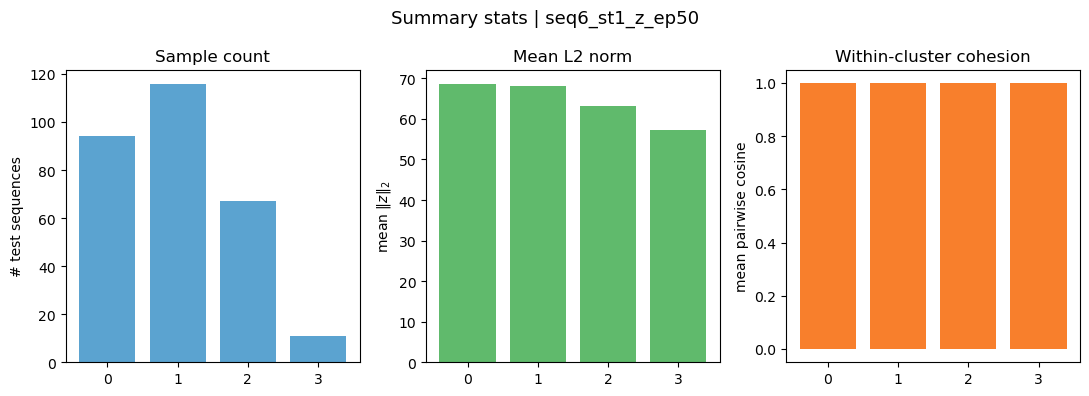

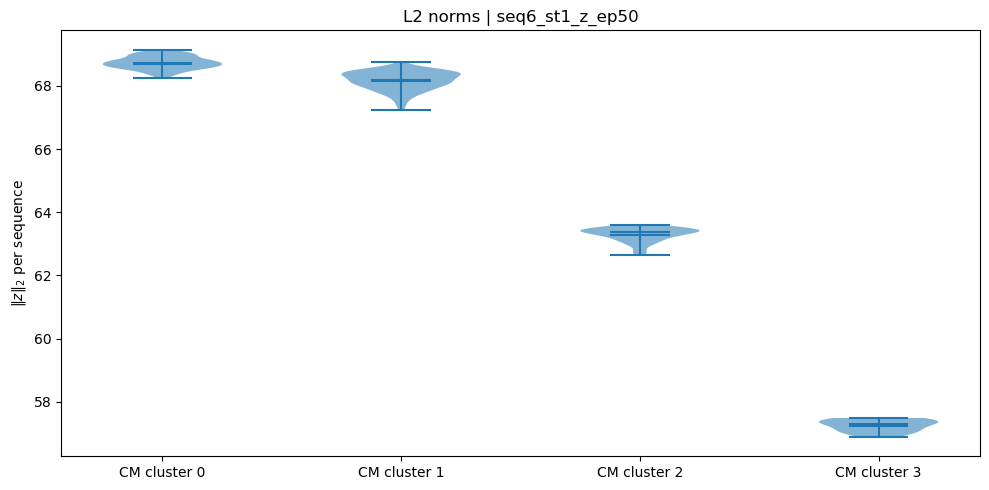

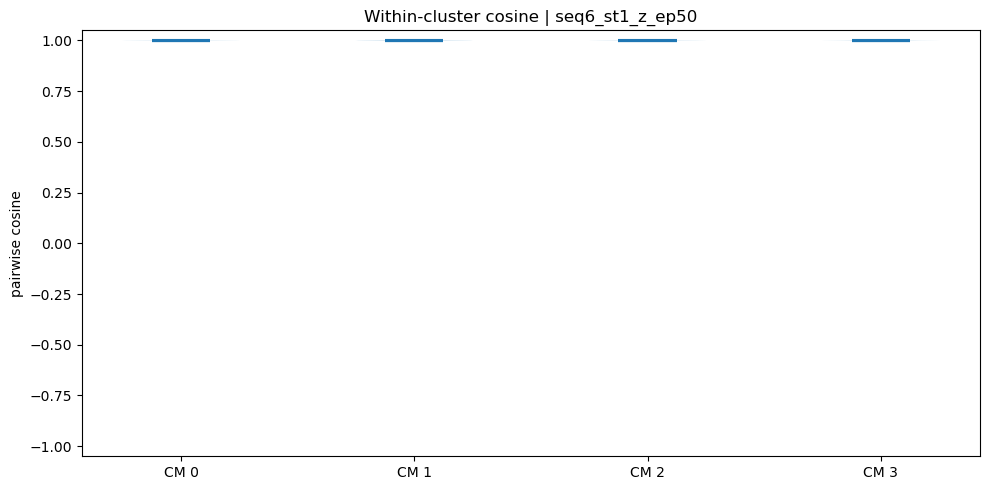

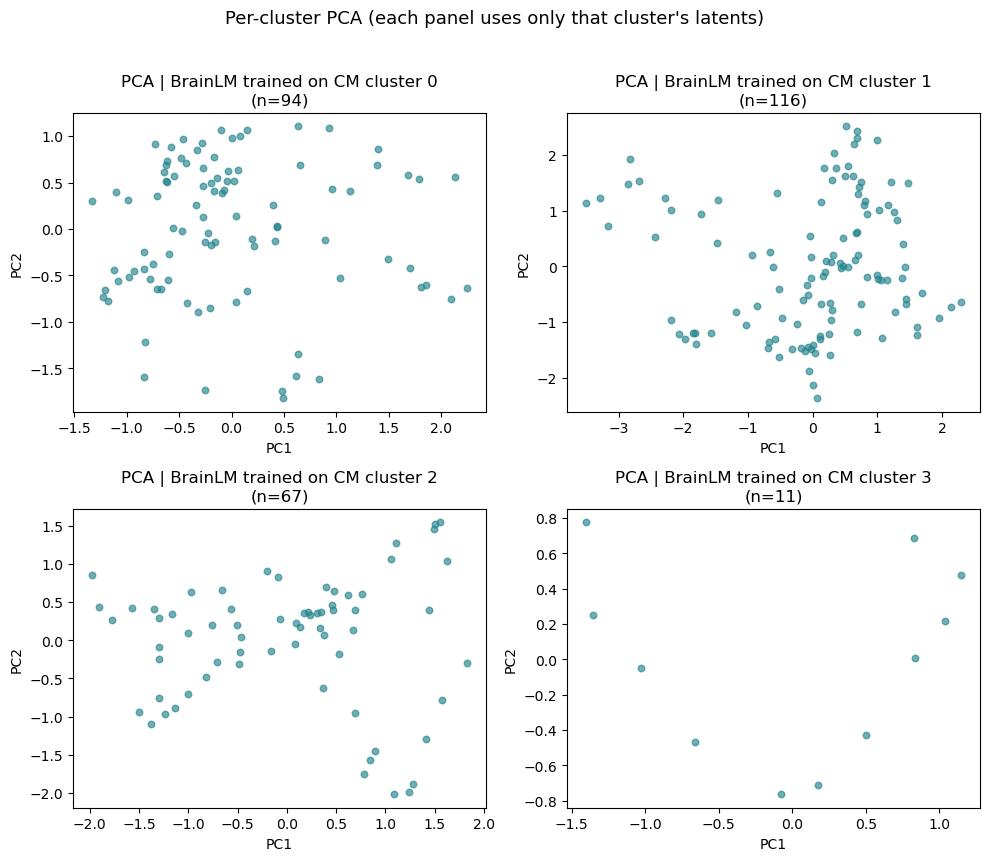

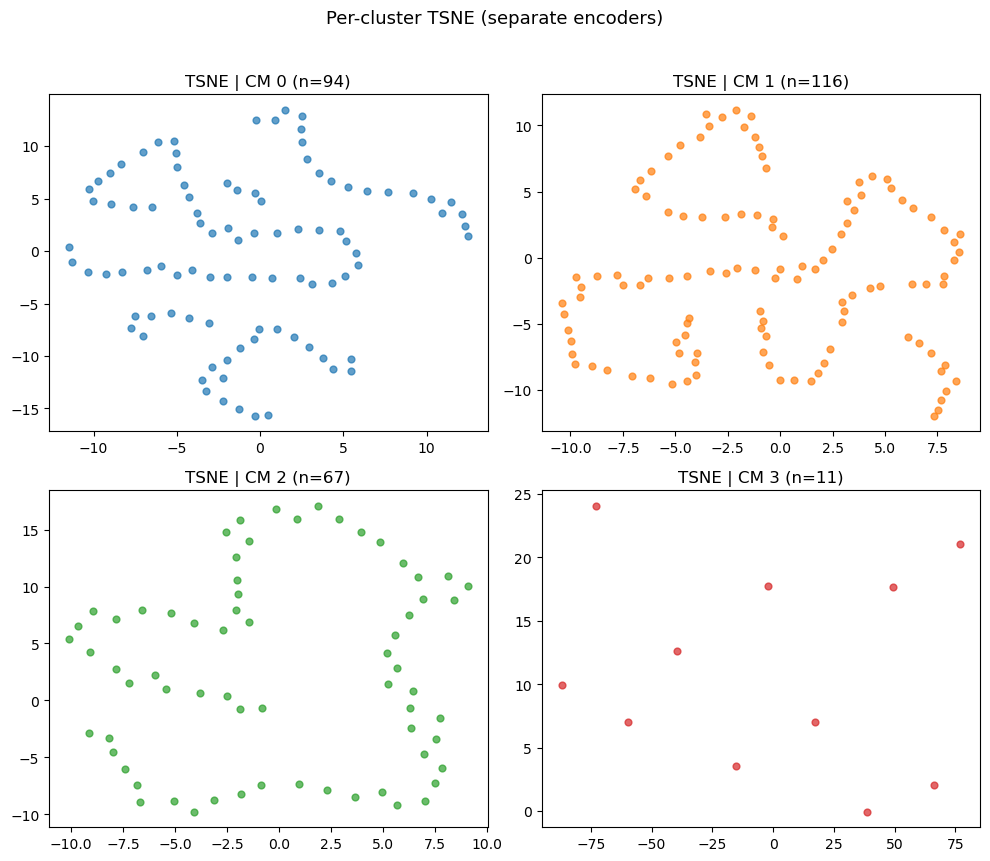

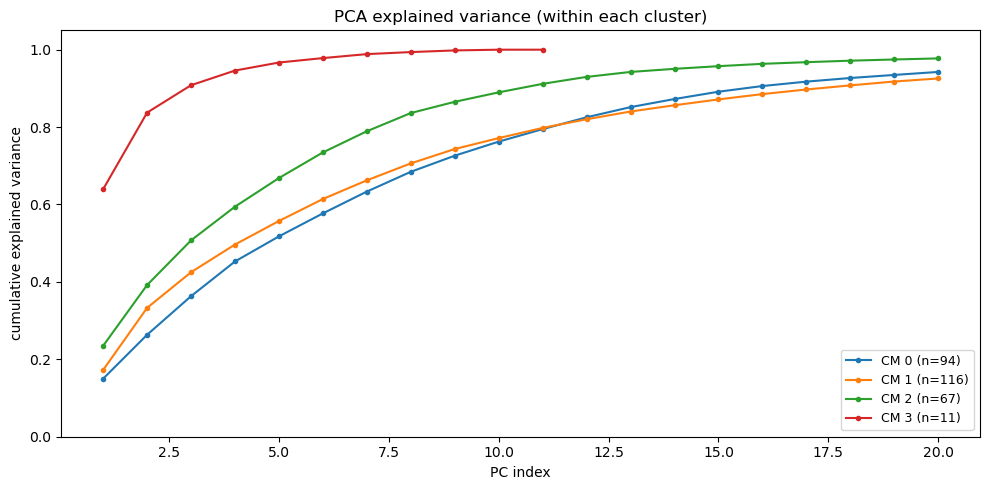

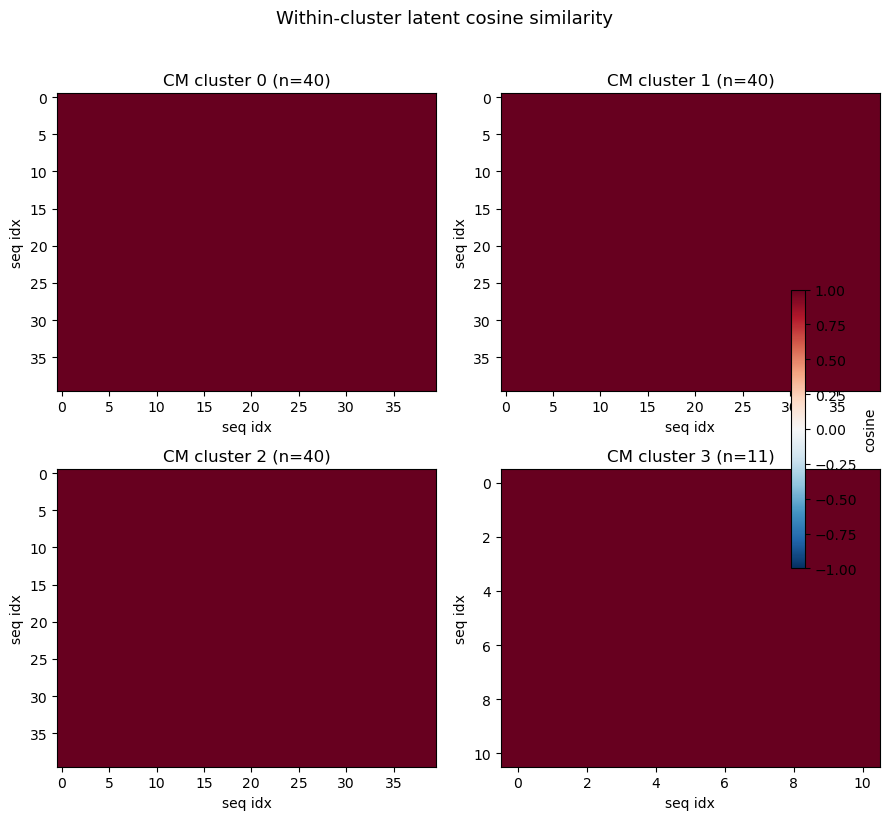

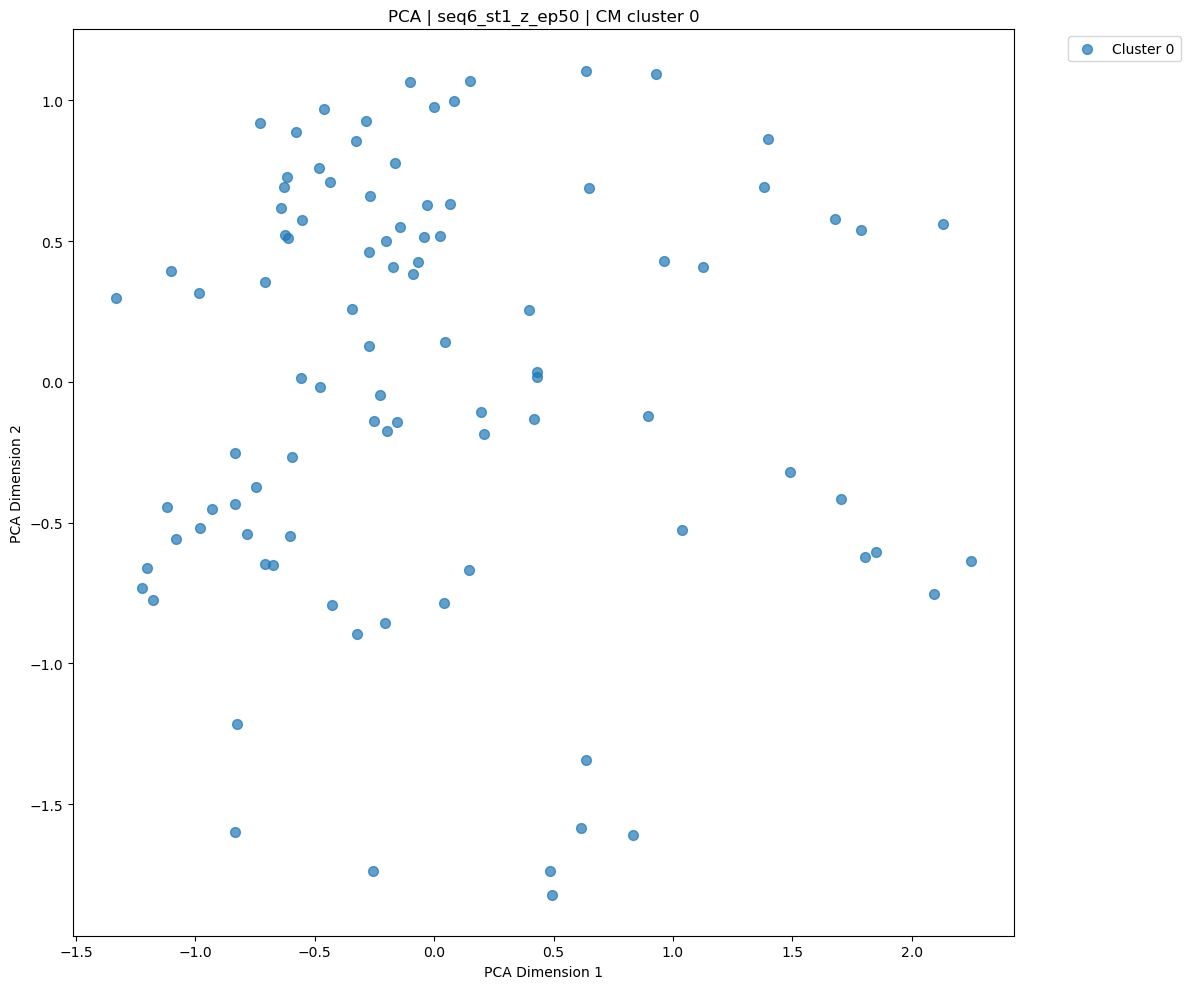

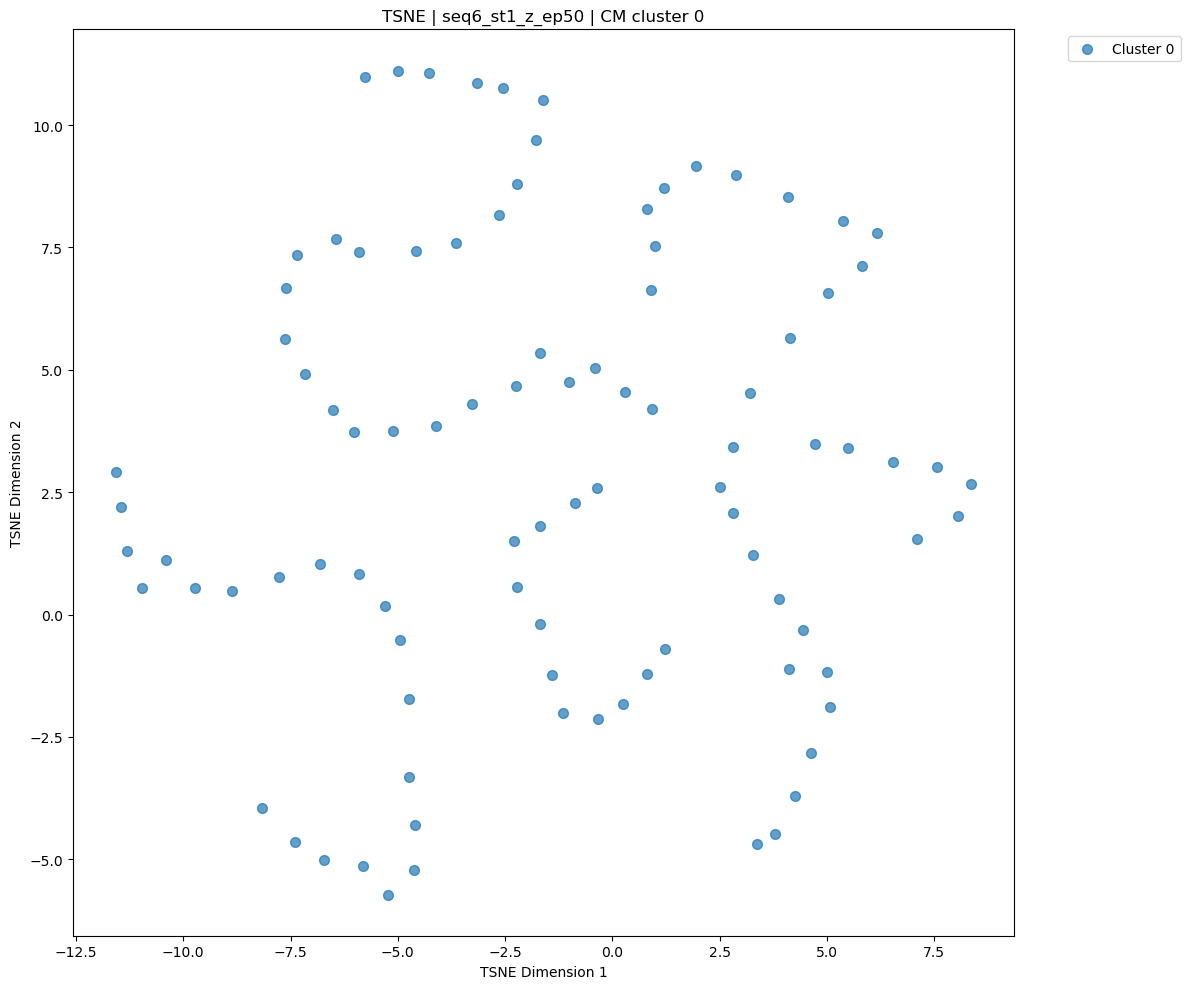

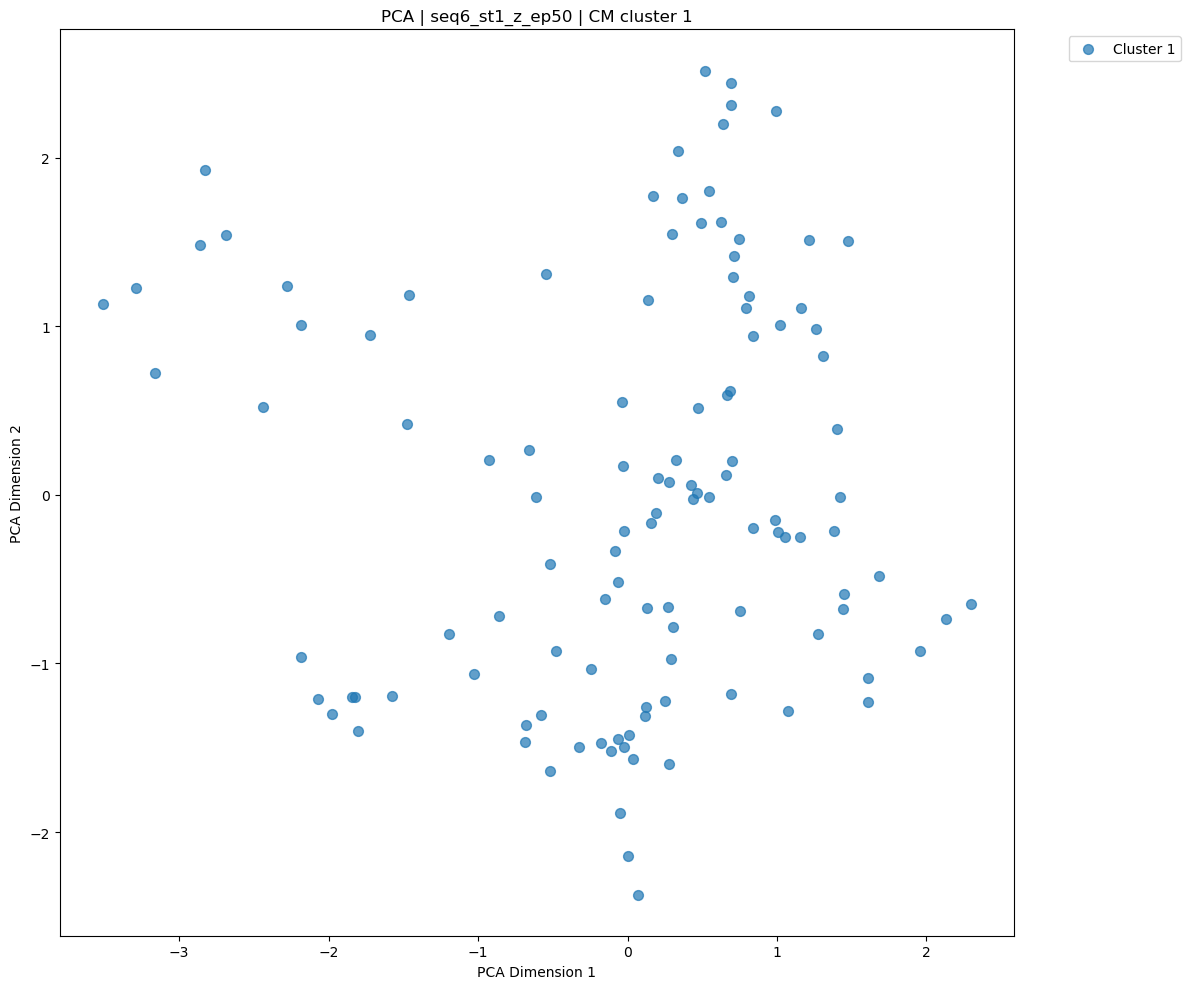

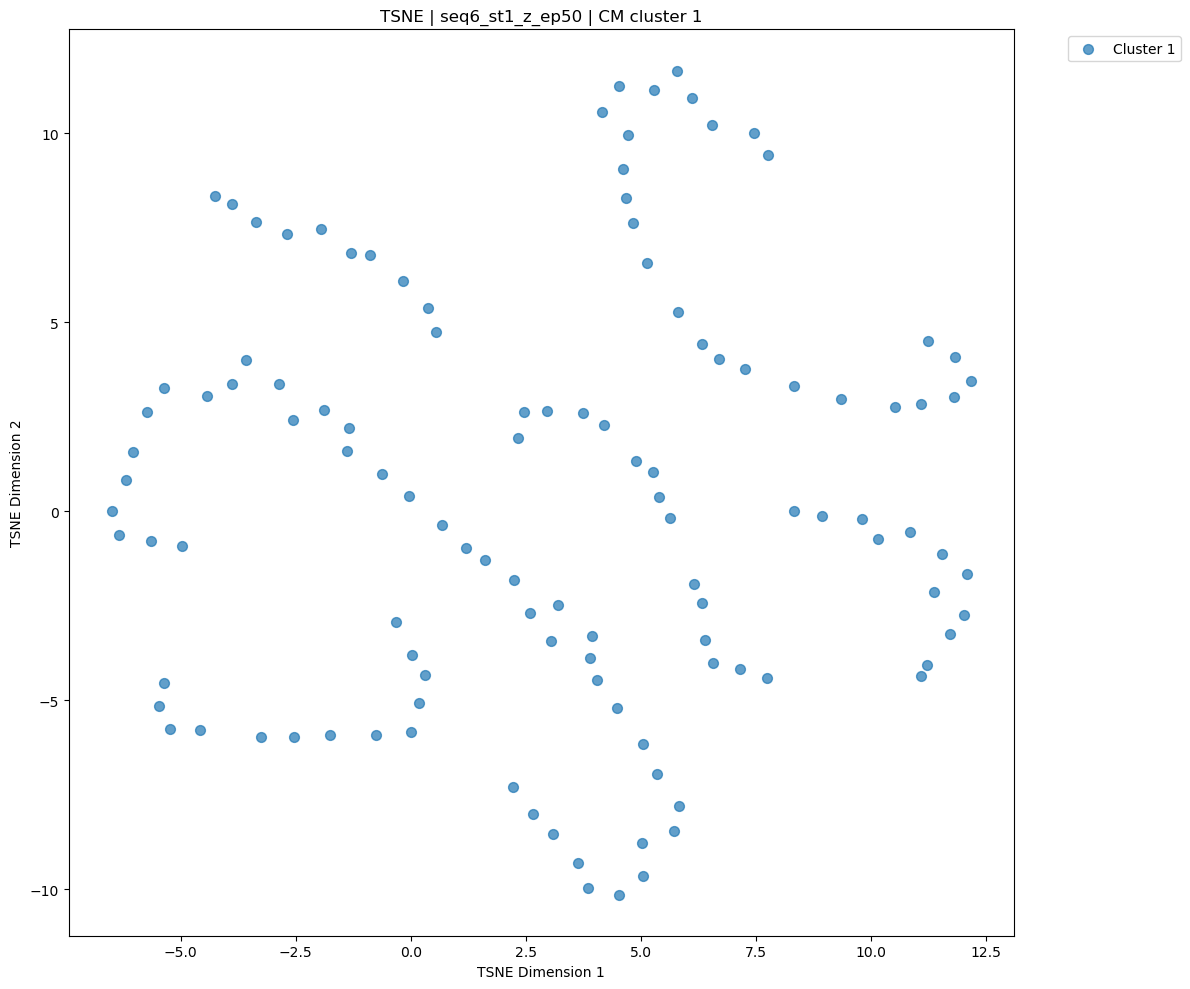

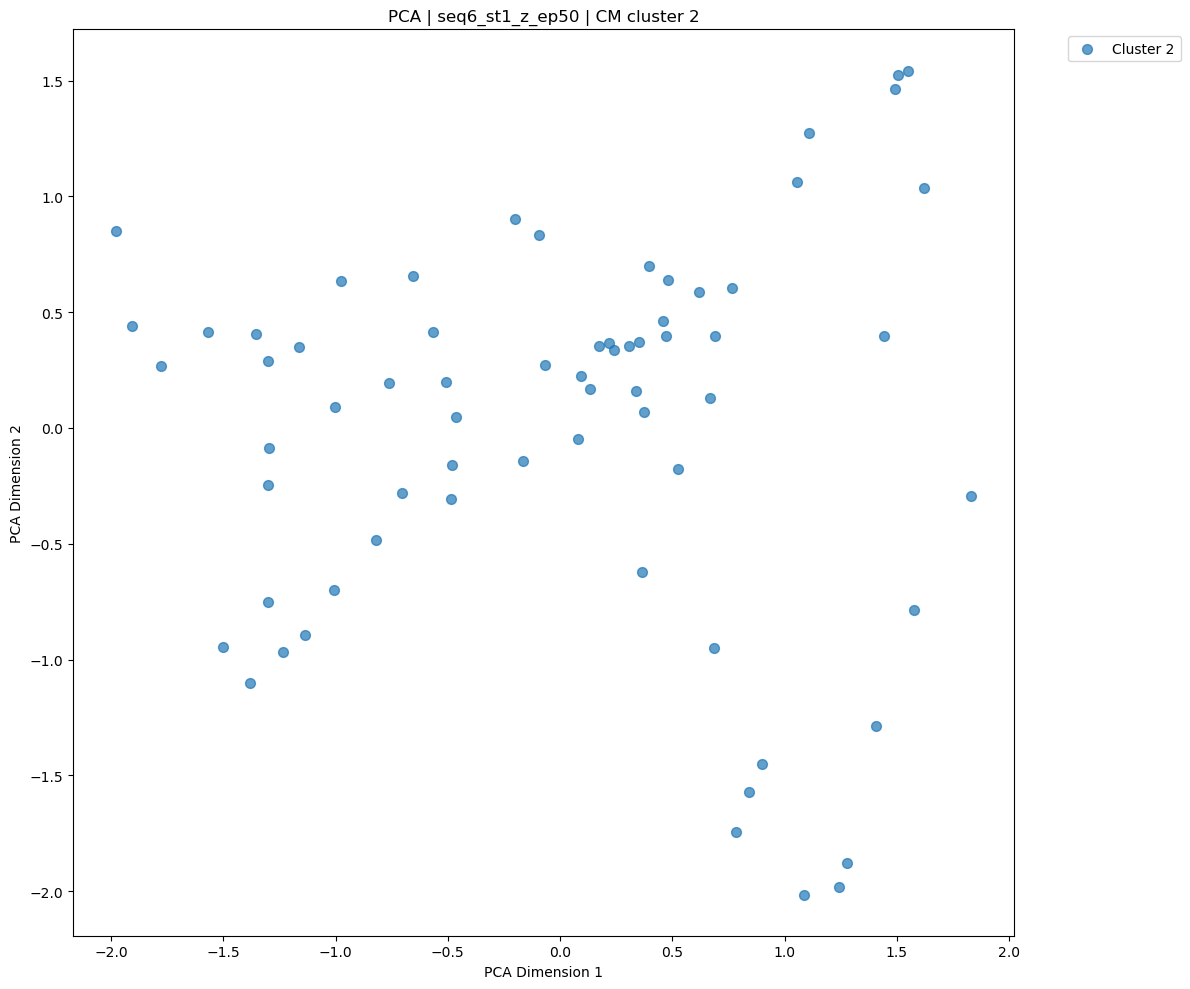

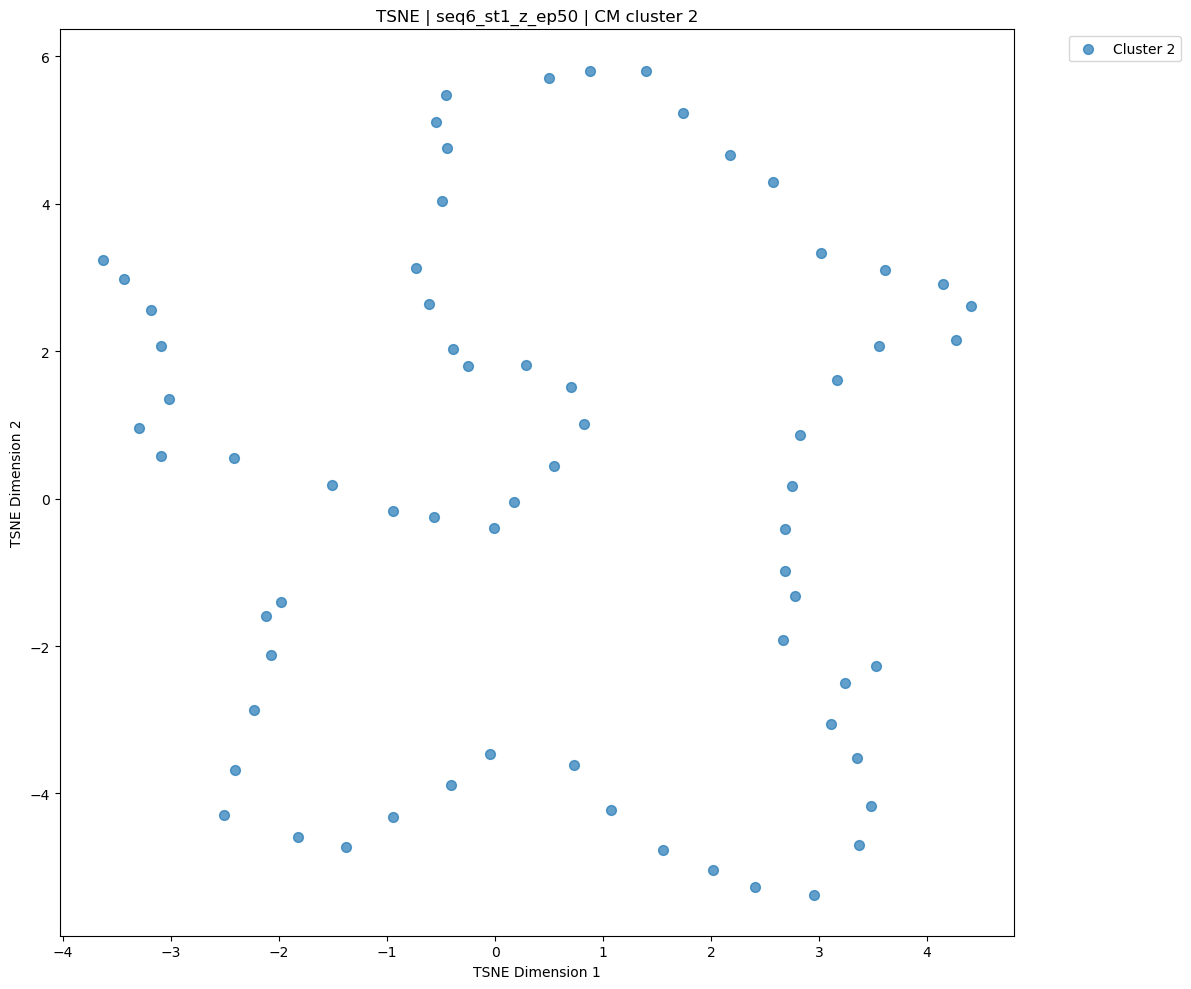

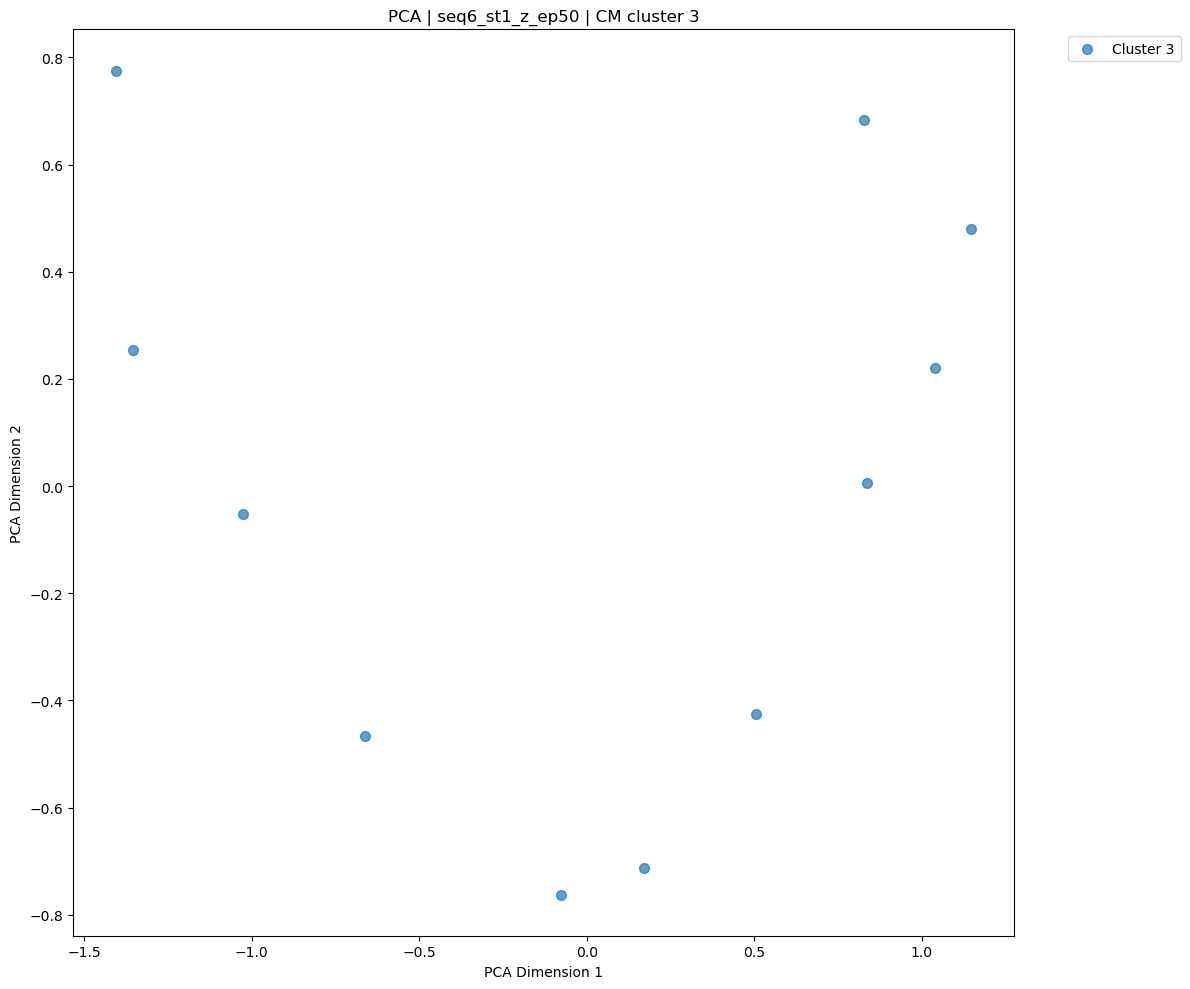

In [17]:
# --- Latent comparison visualizations (final BrainLM run only; not grid) ---
# Latents were extracted on train+val+test (manifold exploration). Test loss is in summary JSON.
# Saves figures under final_runs/<tag>/latent_compare/

from pathlib import Path
import json
import numpy as np

from pipeline.visualization import (
    visualize_latents,
    plot_latent_l2_norms_by_cluster,
    plot_pooled_latents_dimred,
    plot_per_cluster_pca_grid,
    plot_cluster_latent_mean_cosine_heatmap,
    plot_latent_scalar_stats_bars,
    plot_latent_pairwise_cosine_violin,
    plot_within_cluster_cosine_heatmaps,
    plot_latent_mean_vector_heatmap,
    plot_pca_explained_variance_per_cluster,
    plot_per_cluster_embedding_grid,
    plot_pooled_latents_methods_panel,
    plot_single_sample_latent_profiles,
)

FINAL_DIR = OUTPUT_PATH / 'final_runs'
if 'summary_path' in globals() and Path(summary_path).exists():
    summary_path = Path(summary_path)
elif 'final_tag' in globals():
    summary_path = FINAL_DIR / final_tag / f'pipeline_summary_{final_tag}.json'
else:
    _guess = 'seq6_st1_z_ep50'
    summary_path = FINAL_DIR / _guess / f'pipeline_summary_{_guess}.json'

if not summary_path.exists():
    raise FileNotFoundError(
        f"Missing summary: {summary_path}\n"
        "Run the final training cell first."
    )

with open(summary_path, 'r') as f:
    cluster_items = json.load(f).get('clusters', [])

run_name = summary_path.parent.name
out_dir = summary_path.parent / 'latent_compare'
out_dir.mkdir(parents=True, exist_ok=True)

# Load all latents (keep n=1 for profile plots; dimred needs n>=2)
all_latents = {}
cluster_latents = {}
for item in cluster_items:
    cid = int(item['cluster_id'])
    lat_path = Path(item['latents_path'])
    if not lat_path.exists():
        print(f"[skip] missing latents for cluster {cid}: {lat_path}")
        continue
    lat = np.load(lat_path)
    if lat.ndim != 2:
        print(f"[skip] unexpected shape cluster {cid}: {lat.shape}")
        continue
    all_latents[cid] = lat
    if lat.shape[0] >= 2 and lat.shape[1] >= 2:
        cluster_latents[cid] = lat
    else:
        print(f"[note] cluster {cid}: shape={lat.shape} — scalar/profile plots only")

if not all_latents:
    raise RuntimeError('No latent arrays found in summary.')

print('Test latent shapes (PCA/t-SNE need n_test>=2; profile bar if n_test==1):')
for cid in sorted(all_latents):
    lat = all_latents[cid]
    in_dimred = cid in cluster_latents
    print(f"  CM cluster {cid}: {lat.shape}  -> dimred={'yes' if in_dimred else 'profile/summary only'}")

def _save(fig, name):
    p = out_dir / name
    fig.savefig(p, dpi=150, bbox_inches='tight')
    print('Saved:', p)

# A) Cross-cluster scalar summaries
_save(plot_latent_scalar_stats_bars(all_latents, title=f'Summary stats | {run_name}', show=False),
      f'latent_scalar_stats_{run_name}.png')
_save(plot_latent_l2_norms_by_cluster(all_latents, title=f'L2 norms | {run_name}', show=False),
      f'latent_norms_violin_{run_name}.png')
if cluster_latents:
    _save(plot_latent_pairwise_cosine_violin(cluster_latents, title=f'Within-cluster cosine | {run_name}', show=False),
          f'latent_pairwise_cosine_violin_{run_name}.png')

# B) Per-cluster geometry (own BrainLM space)
if cluster_latents:
    _save(plot_per_cluster_pca_grid(cluster_latents, n_cols=2, show=False),
          f'latent_pca_grid_{run_name}.png')
    _save(plot_per_cluster_embedding_grid(cluster_latents, method='tsne', min_samples=5, n_cols=2, show=False),
          f'latent_tsne_grid_{run_name}.png')
    _save(plot_pca_explained_variance_per_cluster(cluster_latents, show=False),
          f'latent_pca_variance_{run_name}.png')
    _save(plot_within_cluster_cosine_heatmaps(cluster_latents, min_samples=3, show=False),
          f'latent_within_cosine_heatmaps_{run_name}.png')
    for cid, lat in sorted(cluster_latents.items()):
        labels = np.full((lat.shape[0],), cid, dtype=np.int64)
        for method in ('pca', 'tsne'):
            fig = visualize_latents(lat, labels, method=method,
                title=f'{method.upper()} | {run_name} | CM cluster {cid}', show=False)
            _save(fig, f'latent_{method}_{run_name}_cluster{cid}.png')

# C) Mean-vector / cross-cluster (use all_latents so n=1 clusters e.g. CM 3 are included)
if len(all_latents) >= 2:
    _save(plot_latent_mean_vector_heatmap(all_latents, max_dims=48, show=False),
          f'latent_mean_vector_heatmap_{run_name}.png')
    _save(plot_cluster_latent_mean_cosine_heatmap(all_latents, show=False),
          f'latent_mean_cosine_heatmap_{run_name}.png')
if cluster_latents:
    _save(plot_pooled_latents_methods_panel(cluster_latents, methods=('pca', 'tsne', 'umap'), show=False),
          f'latent_pooled_methods_panel_{run_name}.png')
    _save(plot_pooled_latents_dimred(cluster_latents, method='pca', title=f'Pooled PCA | {run_name}', show=False),
          f'latent_pooled_pca_{run_name}.png')

# D) Clusters with only one test sequence
_save(plot_single_sample_latent_profiles(all_latents, show=False),
      f'latent_single_sample_profiles_{run_name}.png')

print('Done. Latent comparison figures:', out_dir)


Cross-cluster comparison | seq6_st1_z_ep50
Latent source: train+val+test per cluster (see pipeline summary)
Shapes:
  CM cluster 0: (94, 256)
  CM cluster 1: (116, 256)
  CM cluster 2: (67, 256)
  CM cluster 3: (11, 256)

Mean latent cosine similarity (1=same direction, 0=orthogonal):


,CM0,CM1,CM2,CM3
CM0,1.000,-0.016,0.024,0.030
CM1,-0.016,1.000,0.014,0.059
CM2,0.024,0.014,1.000,0.058
CM3,0.030,0.059,0.058,1.000


Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/cross_cluster/cross_cluster_mean_cosine_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/cross_cluster/cross_cluster_mean_profile_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/cross_cluster/cross_cluster_pooled_pca_seq6_st1_z_ep50.png
Saved: /Users/mac/Desktop/code/MTAD-GAT/visualization_ver2/final_runs/seq6_st1_z_ep50/latent_compare/cross_cluster/cross_cluster_pooled_tsne_seq6_st1_z_ep50.png

Interpretation cheat-sheet:
  - Heatmap off-diagonal low  => cluster representatives differ (desired for distinct manifolds).
  - Pooled plot: same color mixed => hard to separate after L2-norm (may still differ within each panel).
  - Per-cluster PCA/t-SNE grids (previous cell) = shape INSIDE each cluster, not comparable axes.
Done: /Users/mac/Desktop/

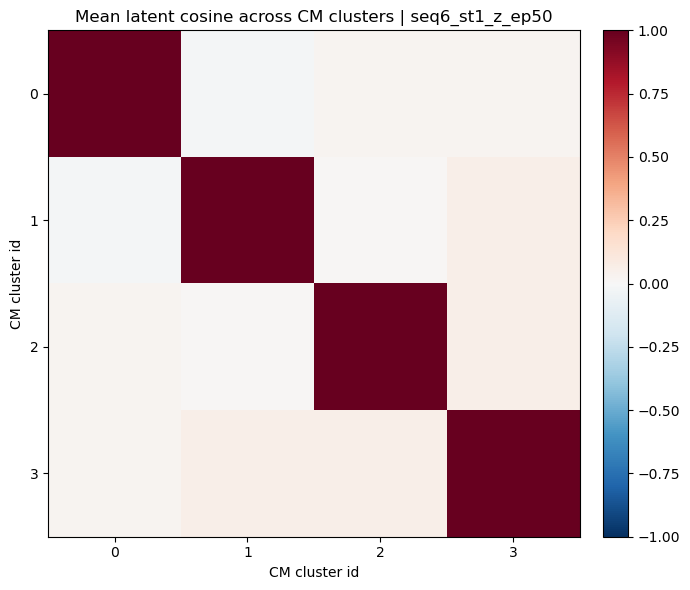

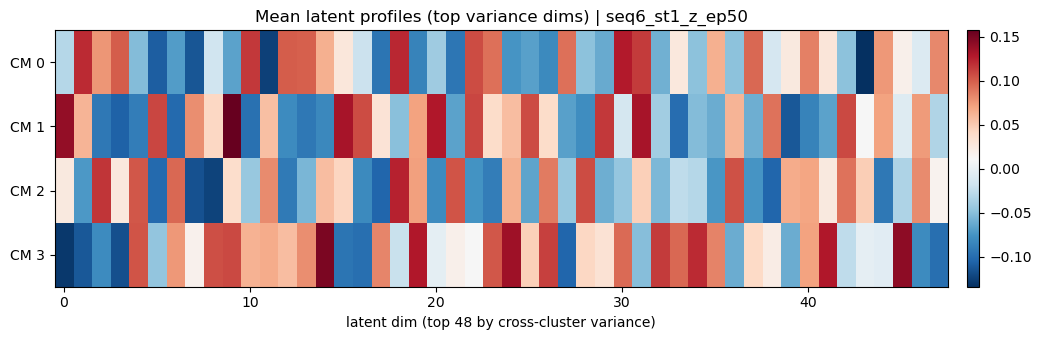

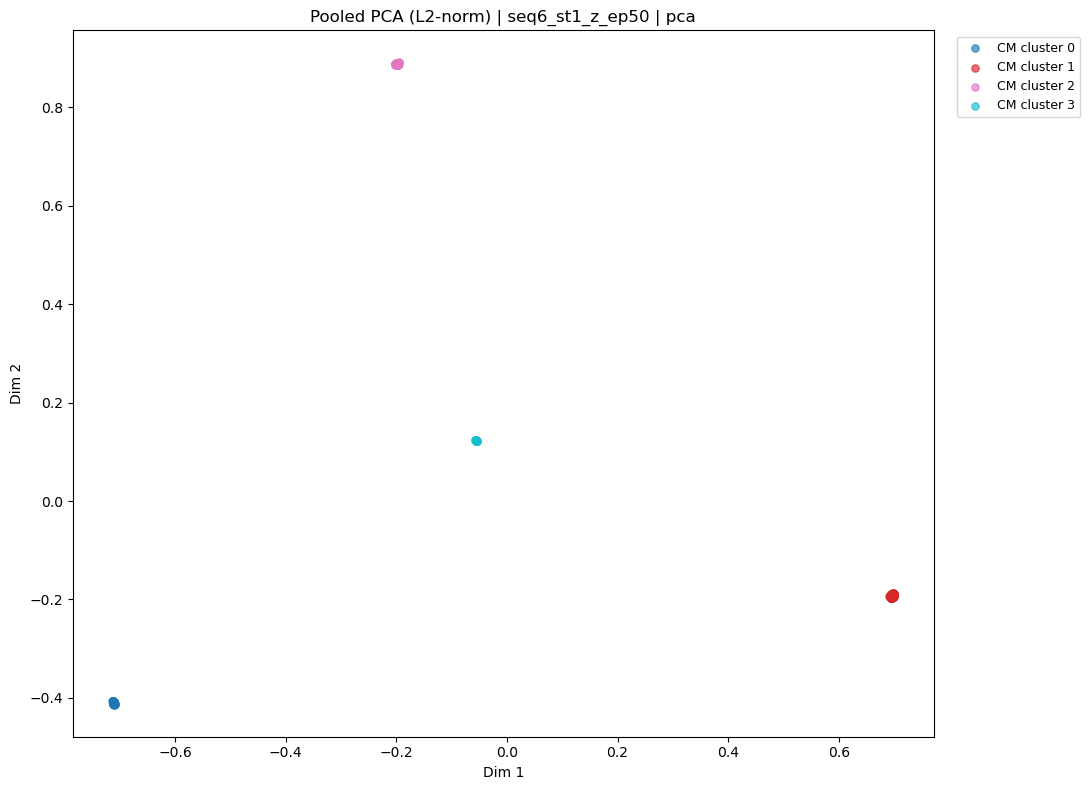

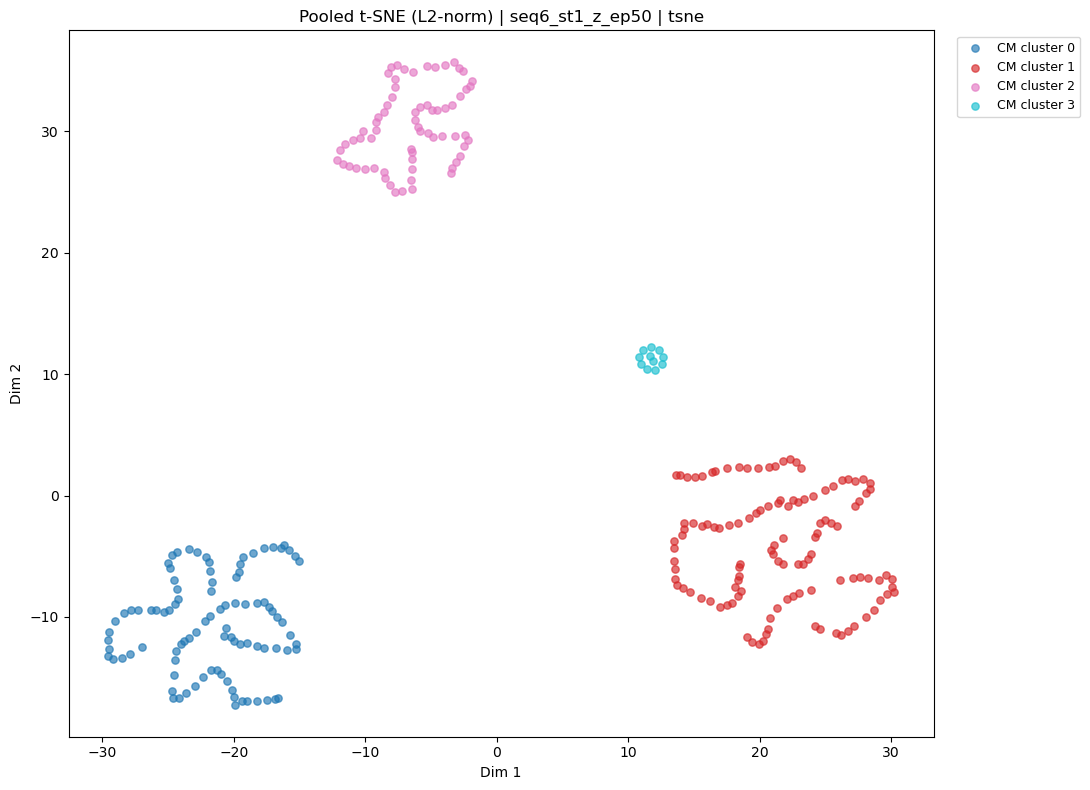

In [18]:
# --- Cross-cluster latent comparison (Are CM clusters different?) ---
# Run after final training + latent_compare cell (or standalone if summary + .npy exist).
#
# How to read:
#   1) Mean cosine heatmap — off-diagonal << 1 => cluster mean latents point in different directions.
#   2) Pooled PCA / t-SNE (L2-normalized) — color=CM cluster; separated blobs => exploratory separation.
#   Note: each cluster has its own BrainLM => pooled plots are exploratory, not a shared metric space.

from pathlib import Path
import json
import numpy as np
import pandas as pd

from pipeline.visualization import (
    plot_cluster_latent_mean_cosine_heatmap,
    plot_pooled_latents_dimred,
    plot_latent_mean_vector_heatmap,
)

# Resolve summary / latents (reuse variables from prior cells when possible)
FINAL_DIR = OUTPUT_PATH / 'final_runs'
if 'all_latents' in globals() and isinstance(all_latents, dict) and len(all_latents) > 0:
    _all_latents = all_latents
    _run_name = str(summary_path.parent.name) if 'summary_path' in globals() else str(final_tag)
    _out_base = Path(summary_path).parent if 'summary_path' in globals() else FINAL_DIR / _run_name
elif 'summary_path' in globals() and Path(summary_path).exists():
    _out_base = Path(summary_path).parent
    _run_name = _out_base.name
    with open(summary_path, 'r') as f:
        _items = json.load(f).get('clusters', [])
    _all_latents = {}
    for item in _items:
        p = Path(item['latents_path'])
        if p.exists():
            _all_latents[int(item['cluster_id'])] = np.load(p)
else:
    _guess = 'seq6_st1_z_ep50'
    _out_base = FINAL_DIR / _guess
    _run_name = _guess
    _sp = _out_base / f'pipeline_summary_{_guess}.json'
    with open(_sp, 'r') as f:
        _items = json.load(f).get('clusters', [])
    _all_latents = {int(it['cluster_id']): np.load(it['latents_path']) for it in _items if Path(it['latents_path']).exists()}

if len(_all_latents) < 2:
    raise RuntimeError('Need latents for >=2 CM clusters. Run final training cell first.')

_dimred_latents = {cid: z for cid, z in _all_latents.items() if z.ndim == 2 and z.shape[0] >= 2 and z.shape[1] >= 2}
_out_dir = _out_base / 'latent_compare' / 'cross_cluster'
_out_dir.mkdir(parents=True, exist_ok=True)

print('=' * 60)
print('Cross-cluster comparison |', _run_name)
print('Latent source: train+val+test per cluster (see pipeline summary)')
print('Shapes:')
for cid in sorted(_all_latents):
    print(f"  CM cluster {cid}: {_all_latents[cid].shape}")
print('=' * 60)

# Numeric: pairwise cosine of mean latent vectors (L2-normalized means)
cids = sorted(_all_latents.keys())
means = []
for cid in cids:
    m = np.asarray(_all_latents[cid], dtype=np.float64).mean(axis=0)
    m = m / (np.linalg.norm(m) + 1e-12)
    means.append(m)
M = np.stack(means, axis=0)
sim = M @ M.T
df_sim = pd.DataFrame(sim, index=[f'CM{c}' for c in cids], columns=[f'CM{c}' for c in cids])
print('\nMean latent cosine similarity (1=same direction, 0=orthogonal):')
display(df_sim.round(3))

def _save(fig, name):
    p = _out_dir / name
    fig.savefig(p, dpi=150, bbox_inches='tight')
    print('Saved:', p)

# 1) Best single figure for "different centroids?"
_save(
    plot_cluster_latent_mean_cosine_heatmap(
        _all_latents,
        title=f'Mean latent cosine across CM clusters | {_run_name}',
        show=False,
    ),
    f'cross_cluster_mean_cosine_{_run_name}.png',
)

_save(
    plot_latent_mean_vector_heatmap(
        _all_latents,
        max_dims=48,
        title=f'Mean latent profiles (top variance dims) | {_run_name}',
        show=False,
    ),
    f'cross_cluster_mean_profile_{_run_name}.png',
)

# 2) Pooled 2D views (need >=2 points per cluster for meaningful spread; uses clusters with n>=2)
if len(_dimred_latents) >= 2:
    _save(
        plot_pooled_latents_dimred(
            _dimred_latents,
            method='pca',
            l2_normalize=True,
            title=f'Pooled PCA (L2-norm) | {_run_name}',
            show=False,
        ),
        f'cross_cluster_pooled_pca_{_run_name}.png',
    )
    _save(
        plot_pooled_latents_dimred(
            _dimred_latents,
            method='tsne',
            l2_normalize=True,
            title=f'Pooled t-SNE (L2-norm) | {_run_name}',
            show=False,
        ),
        f'cross_cluster_pooled_tsne_{_run_name}.png',
    )
else:
    print('[skip] pooled PCA/t-SNE: need >=2 sequences per cluster for dimred')

print('\nInterpretation cheat-sheet:')
print('  - Heatmap off-diagonal low  => cluster representatives differ (desired for distinct manifolds).')
print('  - Pooled plot: same color mixed => hard to separate after L2-norm (may still differ within each panel).')
print('  - Per-cluster PCA/t-SNE grids (previous cell) = shape INSIDE each cluster, not comparable axes.')
print('Done:', _out_dir)